In [96]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [97]:
growth_rates_emissions_energy_prod_income_level_country_df = pd.read_csv("../datasets/growth_rates_emissions_energy_prod_income_level_country_df.csv", index_col=None)

In [98]:
growth_rates_emissions_energy_prod_income_level_country_df.head()

,Unnamed: 0,Country Name,Country Code,Series Name,Series Code,1989_1989,1990_1990,1991_1991,1992_1992,1993_1993,...,2015_2015,2016_2016,2017_2017,2018_2018,2019_2019,2020_2020,2021_2021,2022_2022,2023_2023,Income Level
0,0,Afghanistan,AFG,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,21.708333,21.708333,21.708333,21.708333,21.708333,...,27.6,28.8,30.3,31.4,32.6,33.8,34.9,36.1,36.1,Low income
1,1,Afghanistan,AFG,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,8.479167,8.479167,8.479167,8.479167,8.479167,...,11.4,12.6,13.5,14.5,15.6,16.4,17.4,18.5,18.5,Low income
2,2,Afghanistan,AFG,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,66.031250,66.031250,66.031250,66.031250,66.031250,...,79.5,80.5,81.6,82.6,83.2,83.8,84.5,85.0,85.0,Low income
3,3,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,58.266667,58.266667,58.266667,58.266667,58.266667,...,71.5,97.7,97.7,93.4,97.7,97.7,97.7,85.3,85.3,Low income
4,4,Afghanistan,AFG,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,57.461905,57.461905,57.461905,57.461905,57.461905,...,64.6,97.1,97.1,91.6,97.1,97.1,97.1,81.7,81.7,Low income


In [99]:
growth_rates_emissions_energy_prod_income_level_country_df.shape

(10533, 41)

In [100]:
growth_rates_emissions_energy_prod_income_level_country_df.isnull().sum()

Unnamed: 0      0
Country Name    0
Country Code    0
Series Name     0
Series Code     0
1989_1989       0
1990_1990       0
1991_1991       0
1992_1992       0
1993_1993       0
1994_1994       0
1995_1995       0
1996_1996       0
1997_1997       0
1998_1998       0
1999_1999       0
2000_2000       0
2001_2001       0
2002_2002       0
2003_2003       0
2004_2004       0
2005_2005       0
2006_2006       0
2007_2007       0
2008_2008       0
2009_2009       0
2010_2010       0
2011_2011       0
2012_2012       0
2013_2013       0
2014_2014       0
2015_2015       0
2016_2016       0
2017_2017       0
2018_2018       0
2019_2019       0
2020_2020       0
2021_2021       0
2022_2022       0
2023_2023       0
Income Level    0
dtype: int64

## Income Level Visualisation

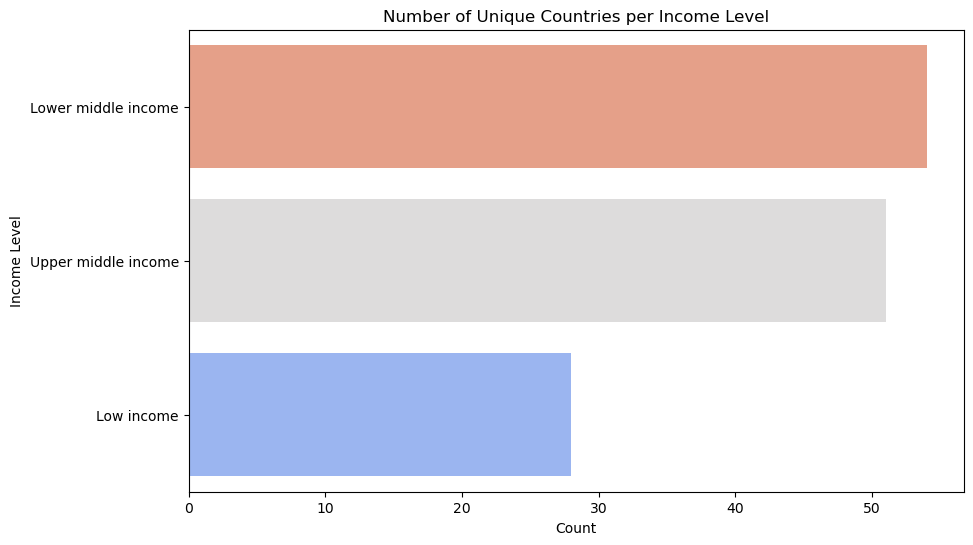

In [102]:
plt.figure(figsize=(10, 6))
unique_countries = growth_rates_emissions_energy_prod_income_level_country_df[["Country Name", "Income Level"]].drop_duplicates()

sns.countplot(y="Income Level", data=unique_countries, hue="Income Level", palette="coolwarm", legend=False, 
              order=unique_countries["Income Level"].value_counts().index)
plt.title("Number of Unique Countries per Income Level")
plt.xlabel("Count")
plt.ylabel("Income Level")
plt.show()

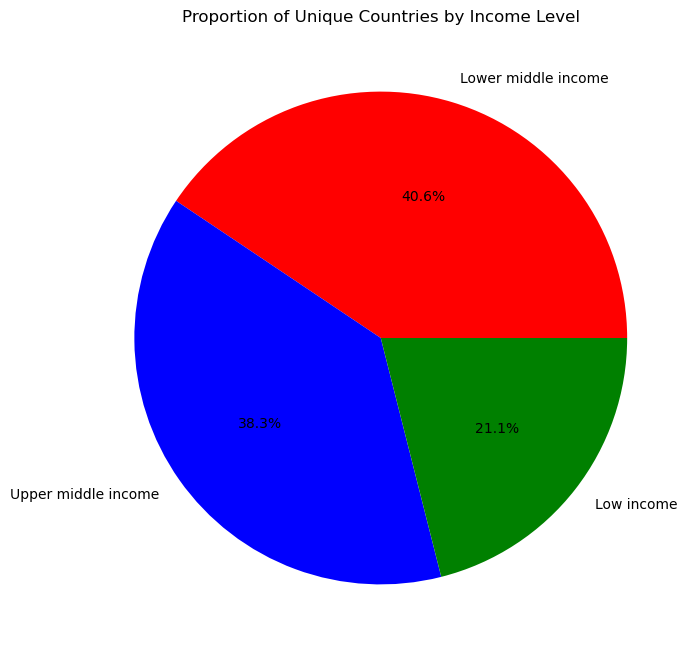

In [103]:
plt.figure(figsize=(8, 8))

unique_countries["Income Level"].value_counts().plot.pie(autopct="%1.1f%%", colors=["red", "blue", "green"])

plt.title("Proportion of Unique Countries by Income Level")
plt.ylabel("")
plt.show()


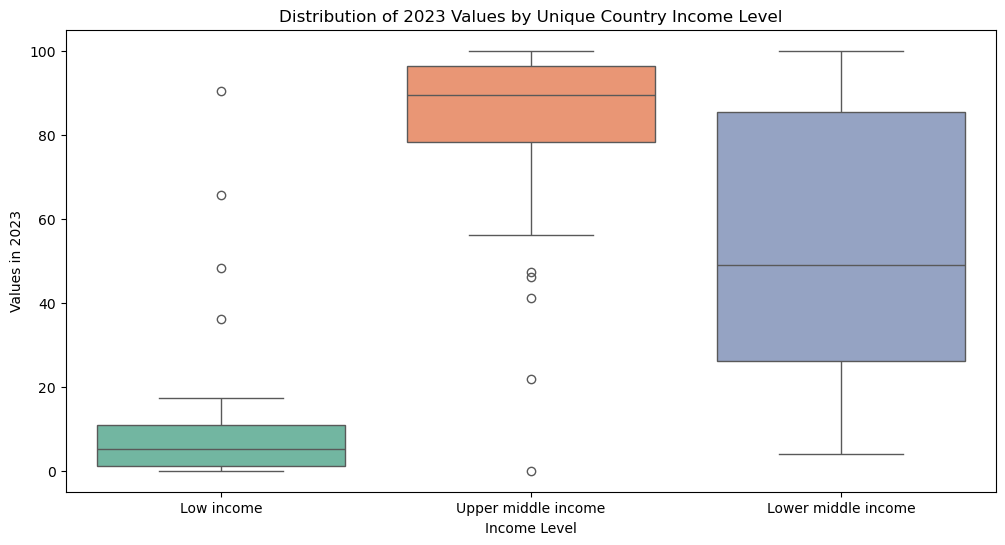

In [104]:
plt.figure(figsize=(12, 6))

unique_countries_df = growth_rates_emissions_energy_prod_income_level_country_df.drop_duplicates(subset=["Country Name"])

sns.boxplot(x="Income Level", y="2023_2023", hue="Income Level", data=unique_countries_df, palette="Set2", legend=False)

plt.title("Distribution of 2023 Values by Unique Country Income Level")
plt.xlabel("Income Level")
plt.ylabel("Values in 2023")
plt.show()

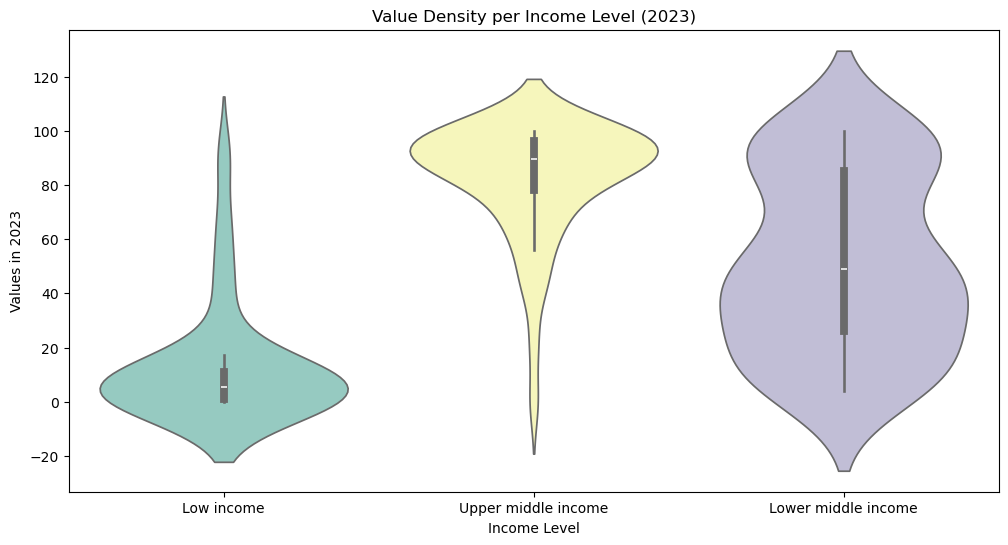

In [105]:
plt.figure(figsize=(12, 6))
sns.violinplot(x="Income Level", y="2023_2023", hue="Income Level", data=unique_countries_df, palette="Set3", legend=False)

plt.title("Value Density per Income Level (2023)")
plt.xlabel("Income Level")
plt.ylabel("Values in 2023")
plt.show()

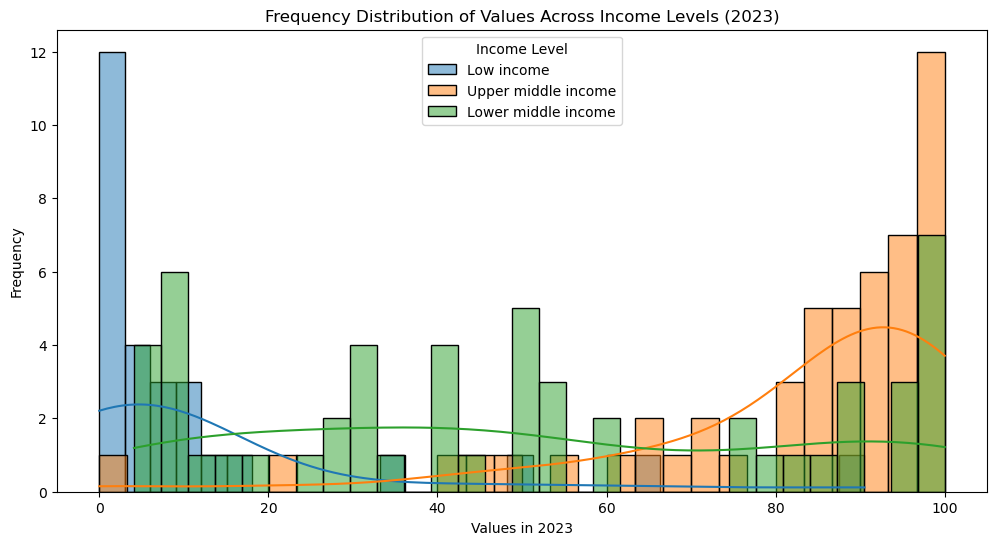

In [106]:
plt.figure(figsize=(12, 6))
for level in unique_countries_df["Income Level"].unique():
    sns.histplot(unique_countries_df[unique_countries_df["Income Level"] == level]["2023_2023"], 
                 label=level, kde=True, bins=30)

plt.legend(title="Income Level")
plt.title("Frequency Distribution of Values Across Income Levels (2023)")
plt.xlabel("Values in 2023")
plt.ylabel("Frequency")
plt.show()

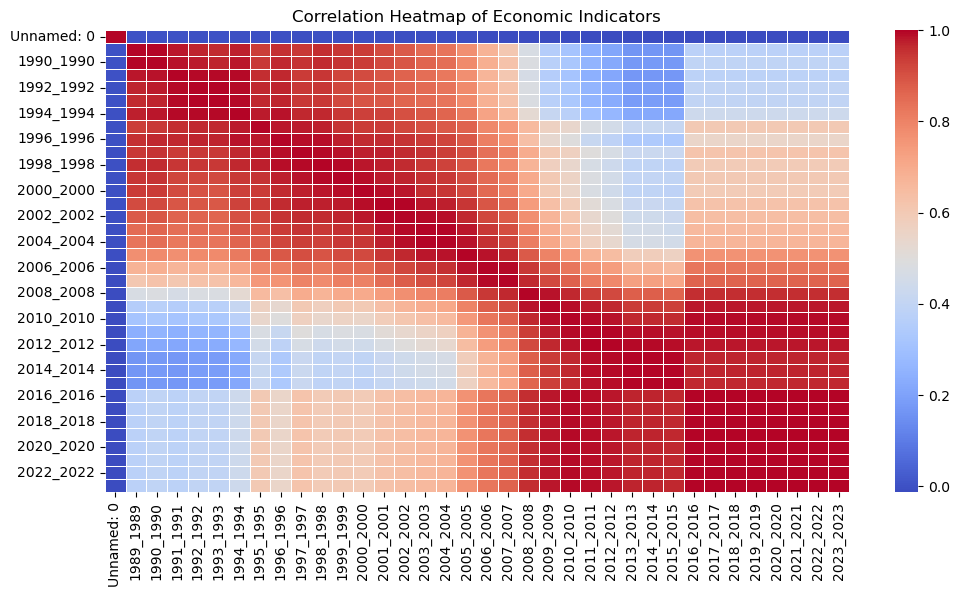

In [107]:
plt.figure(figsize=(12, 6))

# Select only numerical columns
numeric_data = growth_rates_emissions_energy_prod_income_level_country_df.select_dtypes(include=["number"])

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Plot heatmap
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, linewidths=0.5)

plt.title("Correlation Heatmap of Economic Indicators")
plt.show()


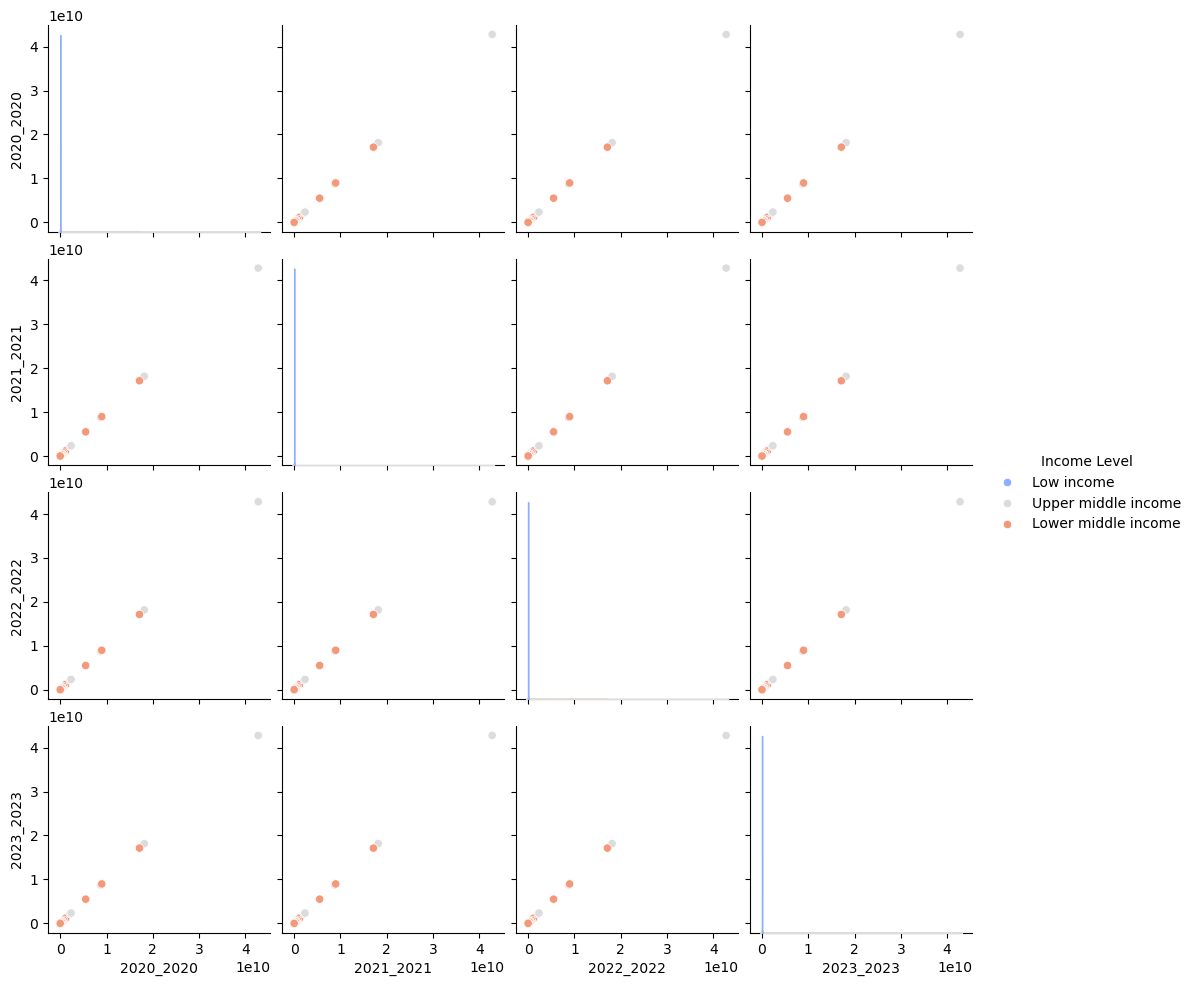

In [108]:
selected_columns = ["2020_2020", "2021_2021", "2022_2022", "2023_2023", "Income Level"]
subset_df = growth_rates_emissions_energy_prod_income_level_country_df[selected_columns].dropna()

# Create a pairplot
sns.pairplot(subset_df, hue="Income Level", palette="coolwarm")

plt.show()


## Top Series Visualisations

In [110]:
# Number of unique series in the dataset
num_series = growth_rates_emissions_energy_prod_income_level_country_df["Series Name"].nunique()
print(f"Total Unique Series: {num_series}")

# Count series occurrences
series_counts = growth_rates_emissions_energy_prod_income_level_country_df["Series Name"].value_counts()

# Display the top series
print("Top 10 Most Frequent Series:\n", series_counts.head(10))

Total Unique Series: 91
Top 10 Most Frequent Series:
 Series Name
Renewable electricity output (% of total electricity output)                                       133
PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)                             132
GDP per capita growth (annual %)                                                                   132
Renewable energy consumption (% of total final energy consumption)                                 132
GDP growth (annual %)                                                                              132
Access to electricity (% of population)                                                            132
PM2.5 air pollution, population exposed to levels exceeding WHO guideline value (% of total)       131
PM2.5 pollution, population exposed to levels exceeding WHO Interim Target-1 value (% of total)    131
PM2.5 pollution, population exposed to levels exceeding WHO Interim Target-2 value (% of total)    131
PM2.5 p

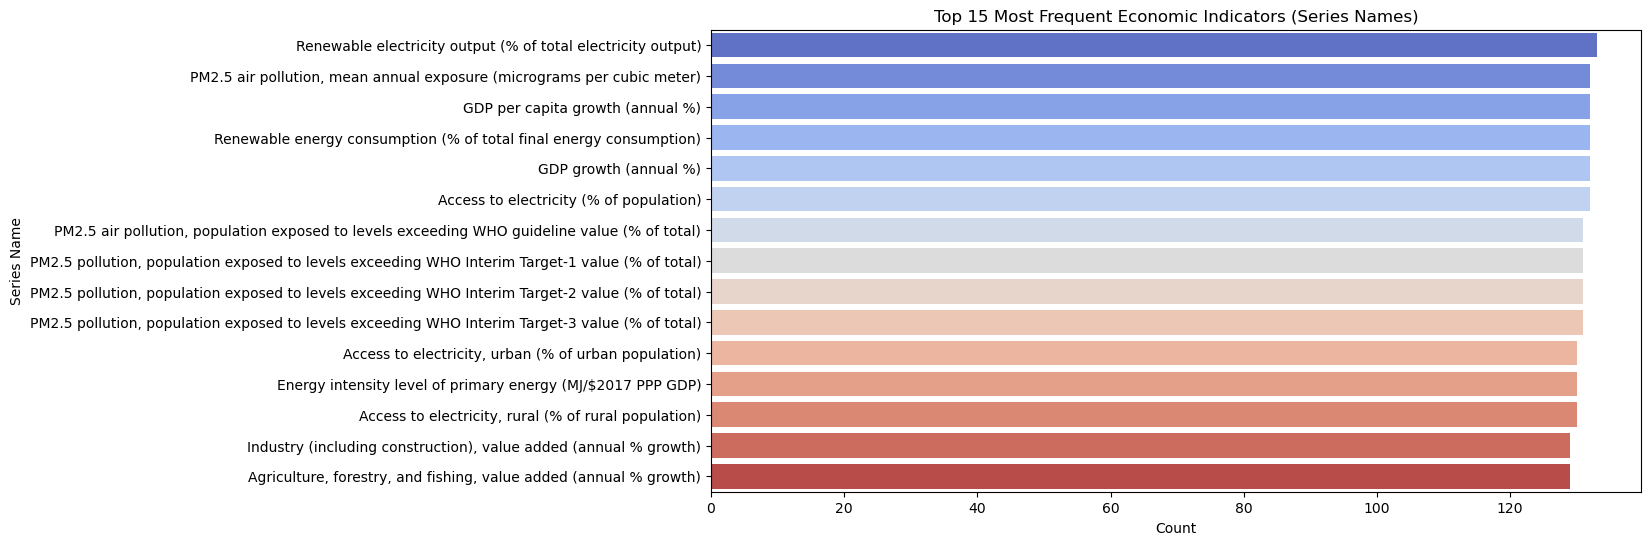

In [111]:
plt.figure(figsize=(12, 6))

# Convert series_counts into a DataFrame
series_df = series_counts.head(15).reset_index()
series_df.columns = ["Series Name", "Count"]

sns.barplot(y="Series Name", x="Count", hue="Series Name", data=series_df, palette="coolwarm", legend=False)

plt.title("Top 15 Most Frequent Economic Indicators (Series Names)")
plt.xlabel("Count")
plt.ylabel("Series Name")
plt.show()


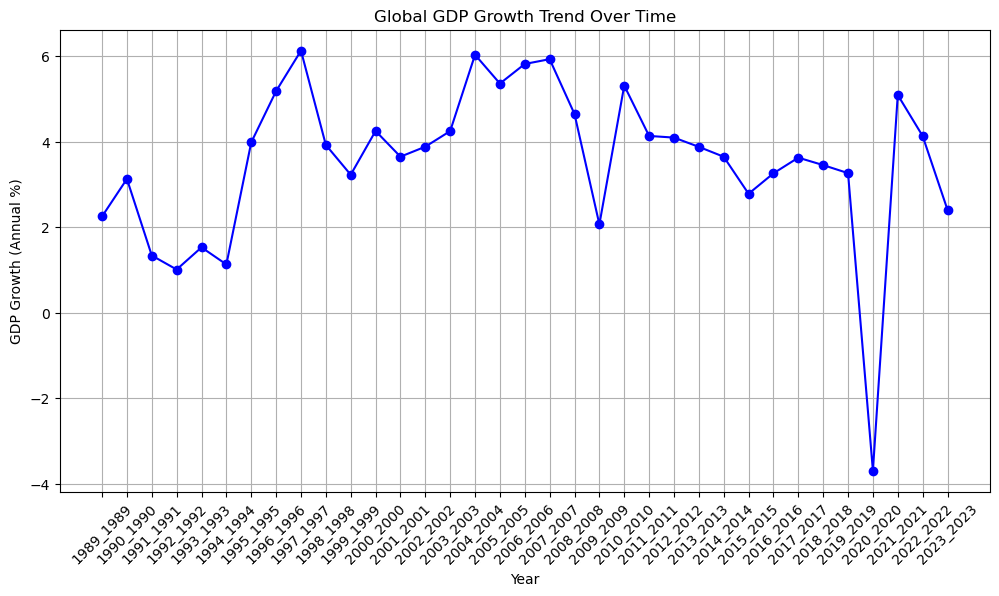

In [112]:
plt.figure(figsize=(12, 6))

growth_rates_emissions_energy_prod_country_df = growth_rates_emissions_energy_prod_income_level_country_df.drop('Income Level', axis = 1)

# Select GDP Growth series
gdp_growth_df = growth_rates_emissions_energy_prod_country_df[
    growth_rates_emissions_energy_prod_country_df["Series Name"] == "GDP growth (annual %)"
]

# Calculate mean GDP Growth per year
gdp_growth_trend = gdp_growth_df.iloc[:, 5:].mean()

# Plot GDP Growth over years
plt.plot(gdp_growth_trend.index, gdp_growth_trend.values, marker="o", linestyle="-", color="blue")

plt.title("Global GDP Growth Trend Over Time")
plt.xlabel("Year")
plt.ylabel("GDP Growth (Annual %)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

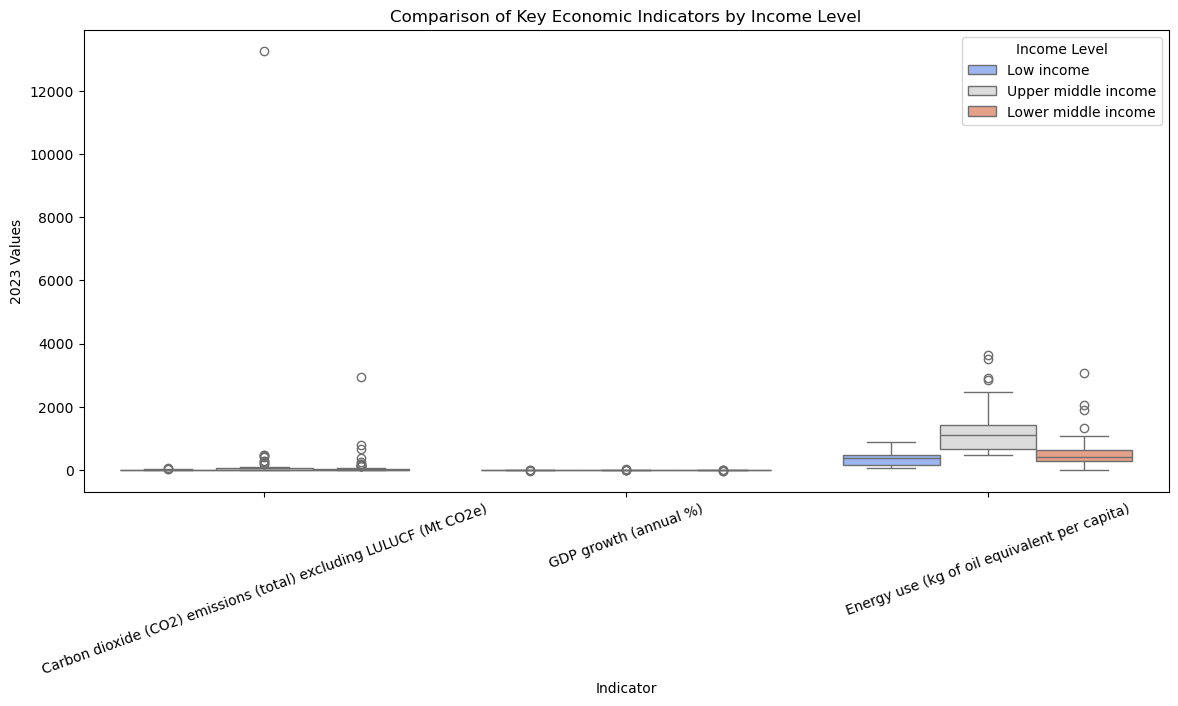

In [113]:
# Select only important economic indicators
selected_series = [
    "GDP growth (annual %)",
    "Energy use (kg of oil equivalent per capita)",
    "Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)"
]

# Filter dataset
subset_df = growth_rates_emissions_energy_prod_income_level_country_df[
    growth_rates_emissions_energy_prod_income_level_country_df["Series Name"].isin(selected_series)
]

# Create box plot
plt.figure(figsize=(14, 6))
sns.boxplot(x="Series Name", y="2023_2023", hue="Income Level", data=subset_df, palette="coolwarm")

plt.title("Comparison of Key Economic Indicators by Income Level")
plt.xlabel("Indicator")
plt.ylabel("2023 Values")
plt.xticks(rotation=20)
plt.legend(title="Income Level")
plt.show()

## Country Based Different Series Visualisations

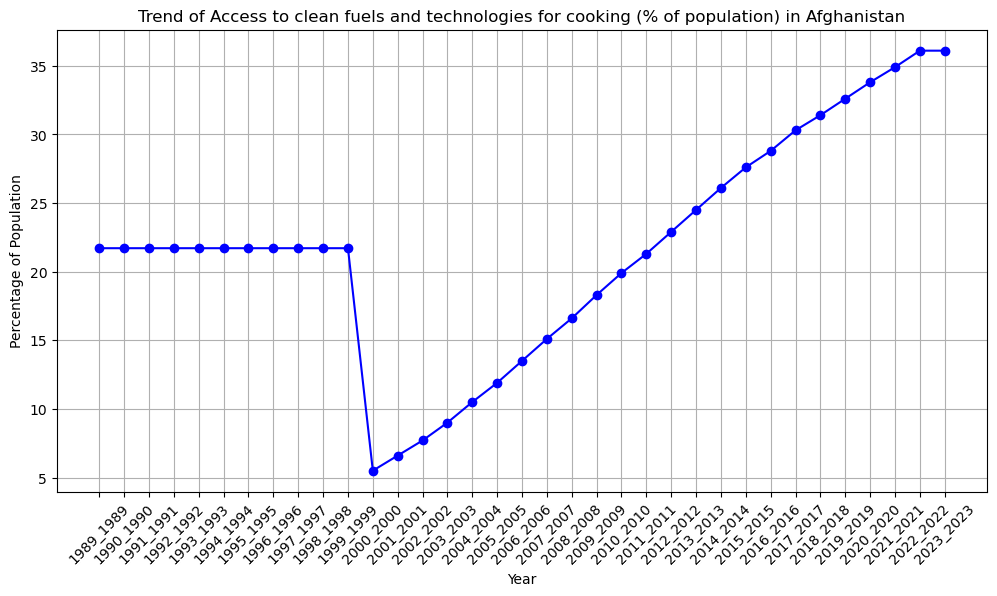

In [115]:
# Filter data for Afghanistan and the selected series
country_name = "Afghanistan"
series_name = "Access to clean fuels and technologies for cooking (% of population)"
afghanistan_series = growth_rates_emissions_energy_prod_country_df[
    (growth_rates_emissions_energy_prod_country_df["Country Name"] == country_name) & 
    (growth_rates_emissions_energy_prod_country_df["Series Name"] == series_name)
]

# Extract years and values
years = afghanistan_series.iloc[:, 5:].columns
values = afghanistan_series.iloc[:, 5:].values.flatten()

# Plot the trend
plt.figure(figsize=(12, 6))
plt.plot(years, values, marker="o", linestyle="-", color="blue")

plt.title(f"Trend of {series_name} in {country_name}")
plt.xlabel("Year")
plt.ylabel("Percentage of Population")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


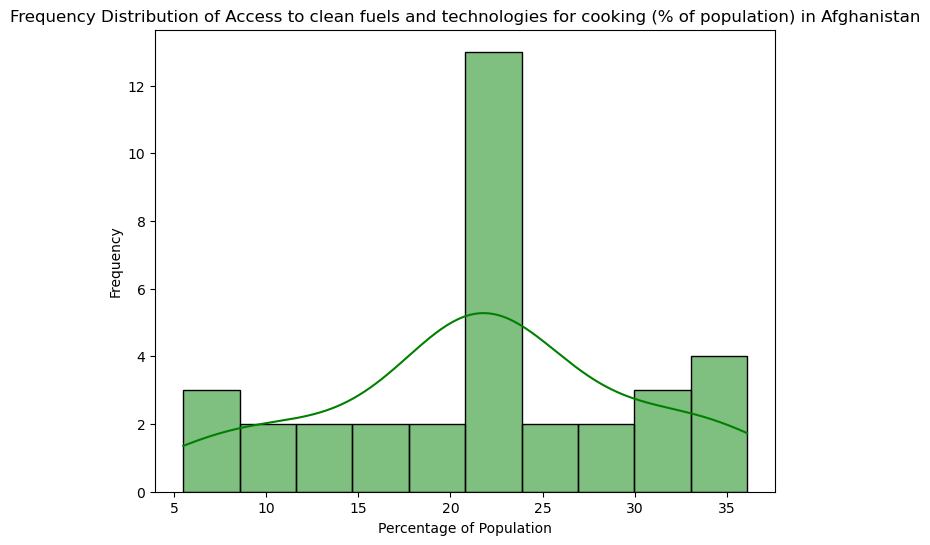

In [118]:
plt.figure(figsize=(8, 6))
sns.histplot(values, bins=10, kde=True, color="green")

plt.title(f"Frequency Distribution of {series_name} in {country_name}")
plt.xlabel("Percentage of Population")
plt.ylabel("Frequency")
plt.show()


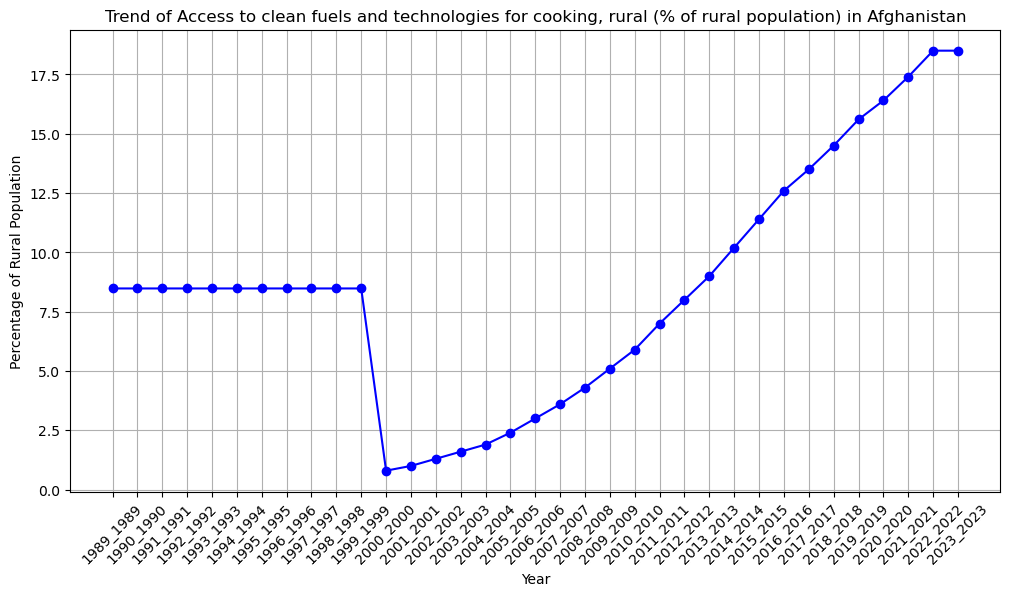

In [119]:
# Select the series
series_name = "Access to clean fuels and technologies for cooking, rural (% of rural population)"
afghanistan_series = growth_rates_emissions_energy_prod_country_df[
    (growth_rates_emissions_energy_prod_country_df["Country Name"] == "Afghanistan") & 
    (growth_rates_emissions_energy_prod_country_df["Series Name"] == series_name)
]

# Extract years and values
years = afghanistan_series.iloc[:, 5:].columns
values = afghanistan_series.iloc[:, 5:].values.flatten()

# Plot trend
plt.figure(figsize=(12, 6))
plt.plot(years, values, marker="o", linestyle="-", color="blue")

plt.title(f"Trend of {series_name} in Afghanistan")
plt.xlabel("Year")
plt.ylabel("Percentage of Rural Population")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


## Groupby income level and list the countries

In [122]:
# Group by Income Level and list unique countries
income_groups = growth_rates_emissions_energy_prod_income_level_country_df.groupby("Income Level")["Country Name"].unique()

# Convert to dictionary for easy access
income_level_countries = {level: list(countries) for level, countries in income_groups.items()}

# Convert to DataFrame for better visualization
income_level_df = pd.DataFrame(dict([(k, pd.Series(v)) for k,v in income_level_countries.items()]))


### Income Level: Low income
#### Series: Access to Clean Fuels and Technologies for Cooking (% of Population)

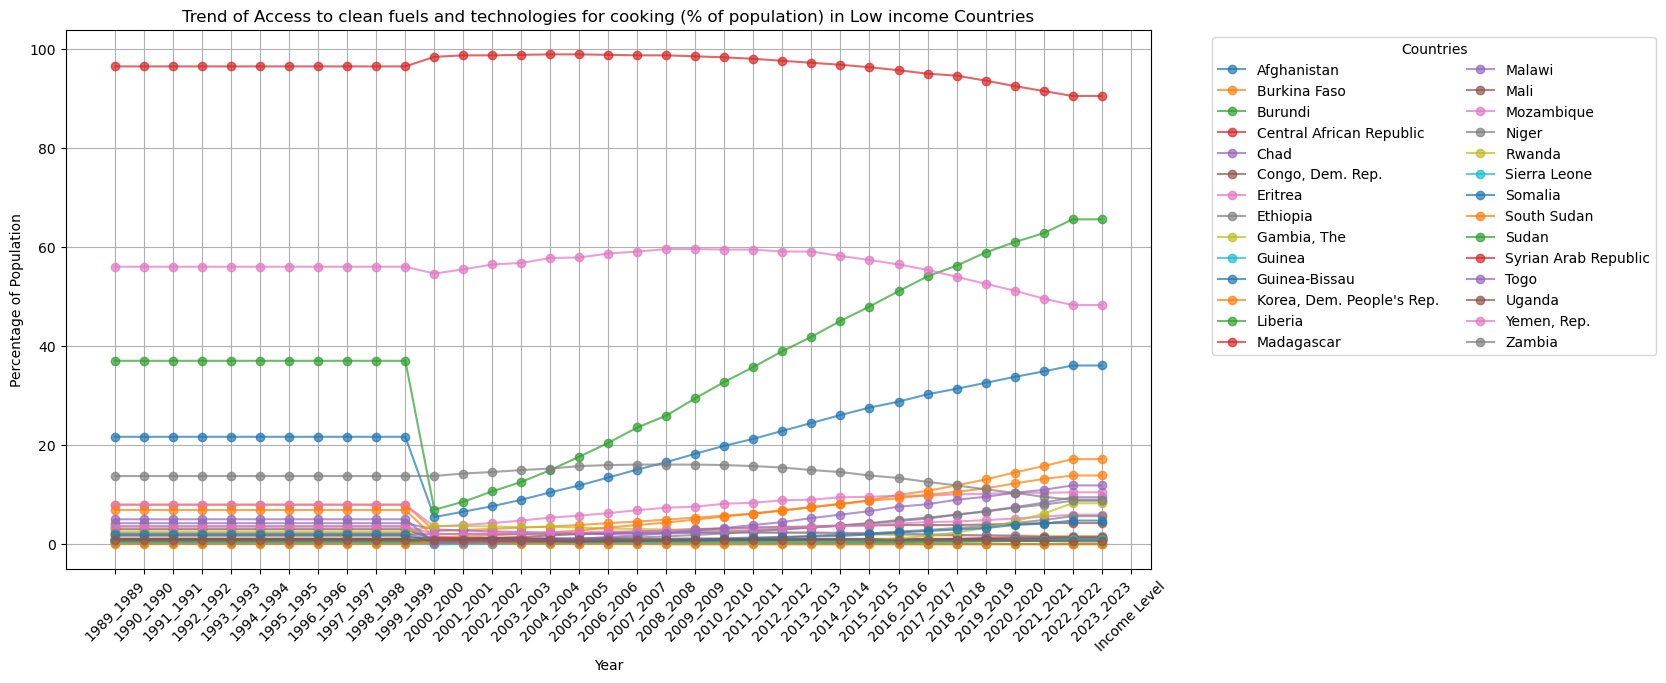

In [124]:
income_level = "Low income"
series_name = "Access to clean fuels and technologies for cooking (% of population)"

low_income_series = growth_rates_emissions_energy_prod_income_level_country_df[
    (growth_rates_emissions_energy_prod_income_level_country_df["Income Level"] == income_level) &
    (growth_rates_emissions_energy_prod_income_level_country_df["Series Name"] == series_name)
]

years = low_income_series.iloc[:, 5:].columns

low_income_series.iloc[:, 5:] = low_income_series.iloc[:, 5:].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(14, 7))
for index, row in low_income_series.iterrows():
    plt.plot(years, row.iloc[5:], label=row["Country Name"], linestyle="-", marker="o", alpha=0.7)

plt.title(f"Trend of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Population")
plt.xticks(rotation=45)
plt.legend(title="Countries", bbox_to_anchor=(1.05, 1), loc="upper left", ncol=2)
plt.grid(True)
plt.show()


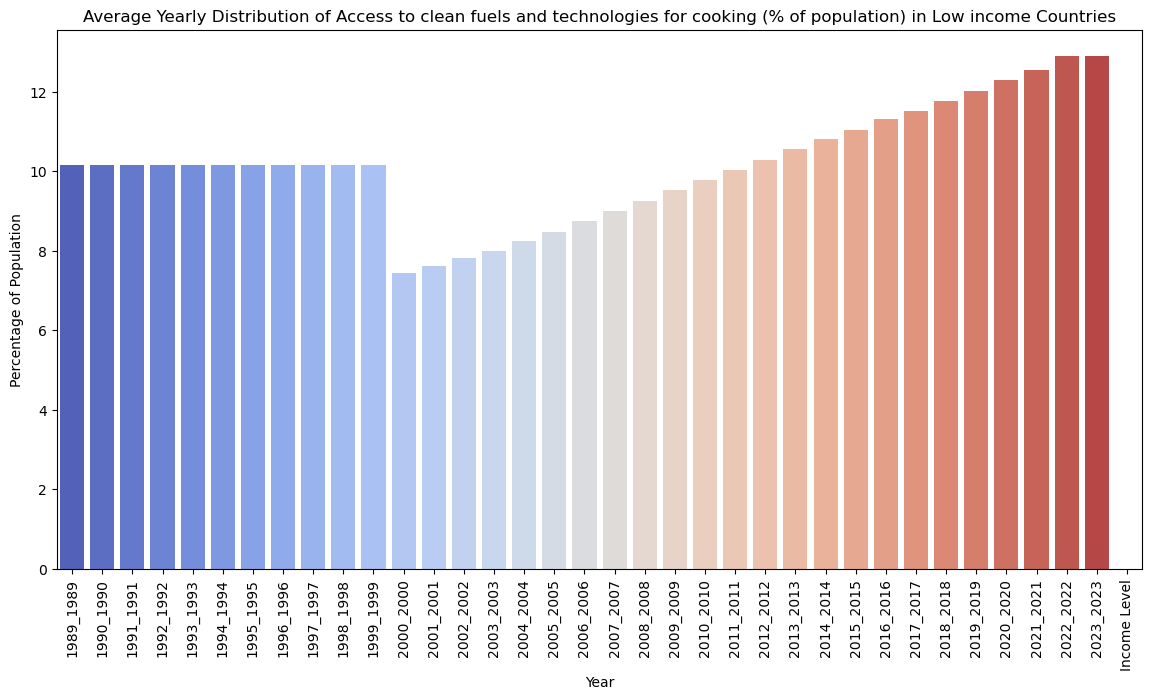

In [125]:
yearly_avg = low_income_series.iloc[:, 5:].mean().reset_index()
yearly_avg.columns = ["Year", "Average Value"]
yearly_avg["Year"] = yearly_avg["Year"].astype(str)

plt.figure(figsize=(14, 7))

sns.barplot(x="Year", y="Average Value", hue="Year", data=yearly_avg, palette="coolwarm", legend=False)

plt.title(f"Average Yearly Distribution of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Population")
plt.xticks(rotation=90)
plt.show()

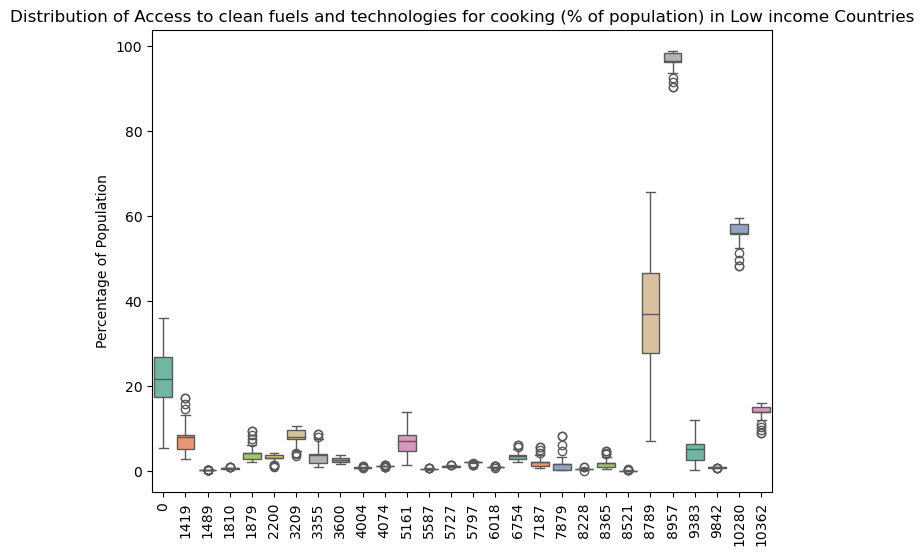

In [126]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=low_income_series.iloc[:, 5:].T, palette="Set2")

plt.title(f"Distribution of {series_name} in {income_level} Countries")
plt.ylabel("Percentage of Population")
plt.xticks(rotation=90)
plt.show()

#### Series: Access to Clean Fuels and Technologies for Cooking, Rural (% of Rural Population)

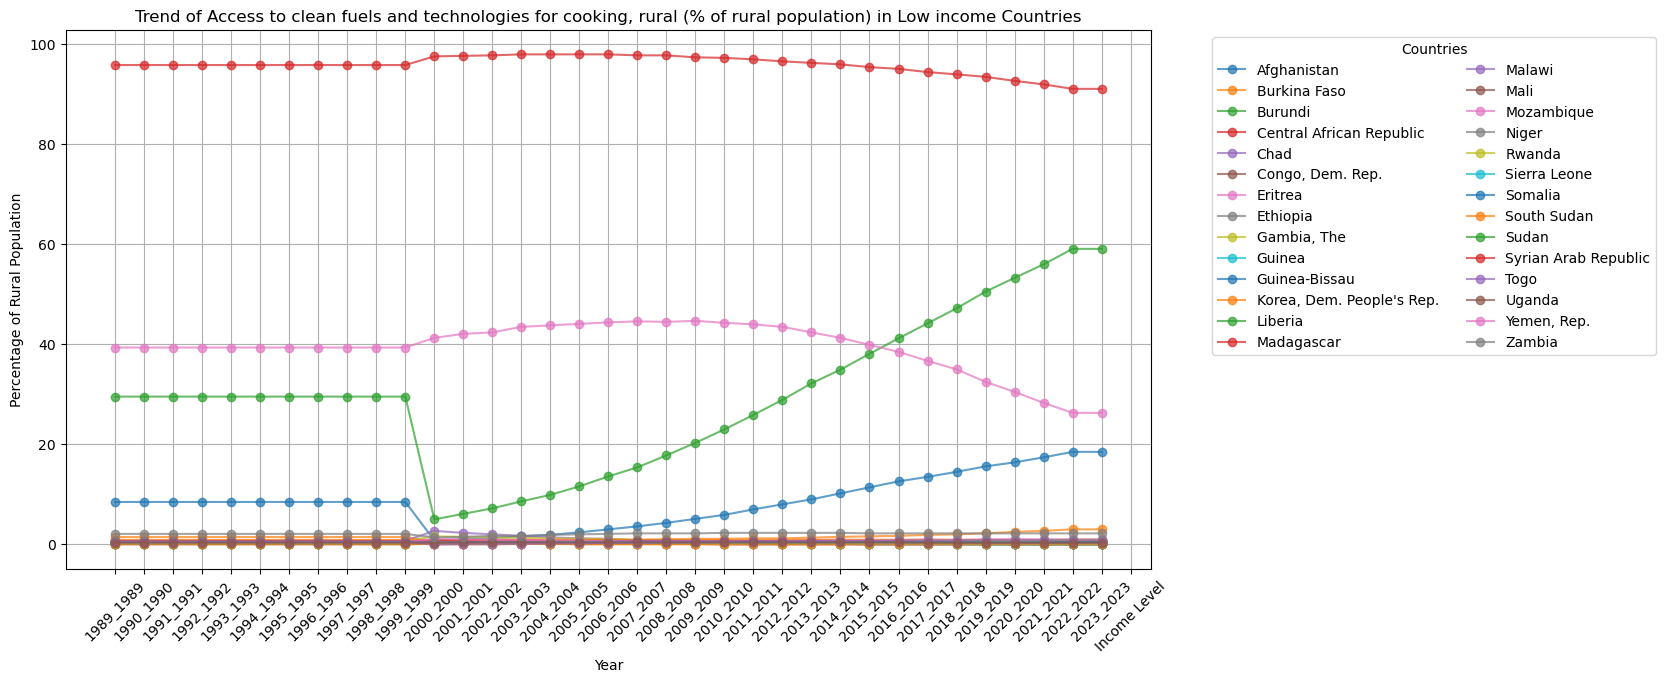

In [128]:
income_level = "Low income"
series_name = "Access to clean fuels and technologies for cooking, rural (% of rural population)"

low_income_series = growth_rates_emissions_energy_prod_income_level_country_df[
    (growth_rates_emissions_energy_prod_income_level_country_df["Income Level"] == income_level) &
    (growth_rates_emissions_energy_prod_income_level_country_df["Series Name"] == series_name)
]

years = low_income_series.iloc[:, 5:].columns

low_income_series.iloc[:, 5:] = low_income_series.iloc[:, 5:].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(14, 7))
for index, row in low_income_series.iterrows():
    plt.plot(years, row.iloc[5:], label=row["Country Name"], linestyle="-", marker="o", alpha=0.7)

plt.title(f"Trend of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Rural Population")
plt.xticks(rotation=45)
plt.legend(title="Countries", bbox_to_anchor=(1.05, 1), loc="upper left", ncol=2)
plt.grid(True)
plt.show()

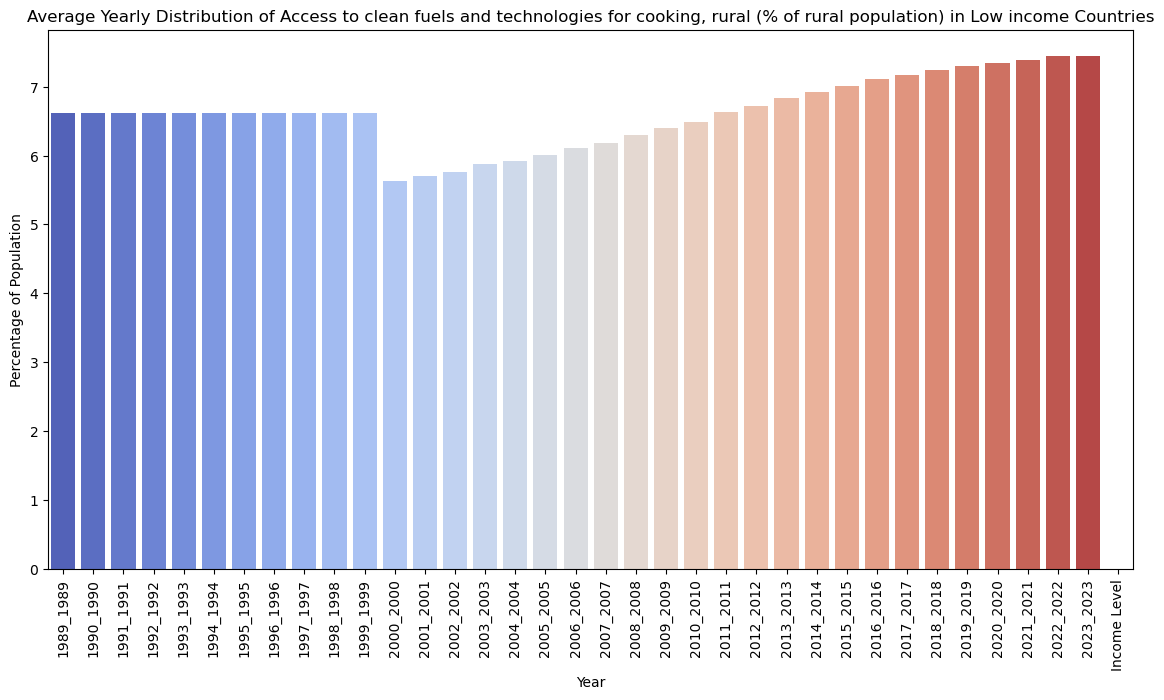

In [129]:
yearly_avg = low_income_series.iloc[:, 5:].mean().reset_index()
yearly_avg.columns = ["Year", "Average Value"]
yearly_avg["Year"] = yearly_avg["Year"].astype(str)

plt.figure(figsize=(14, 7))

sns.barplot(x="Year", y="Average Value", hue="Year", data=yearly_avg, palette="coolwarm", legend=False)

plt.title(f"Average Yearly Distribution of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Population")
plt.xticks(rotation=90)
plt.show()

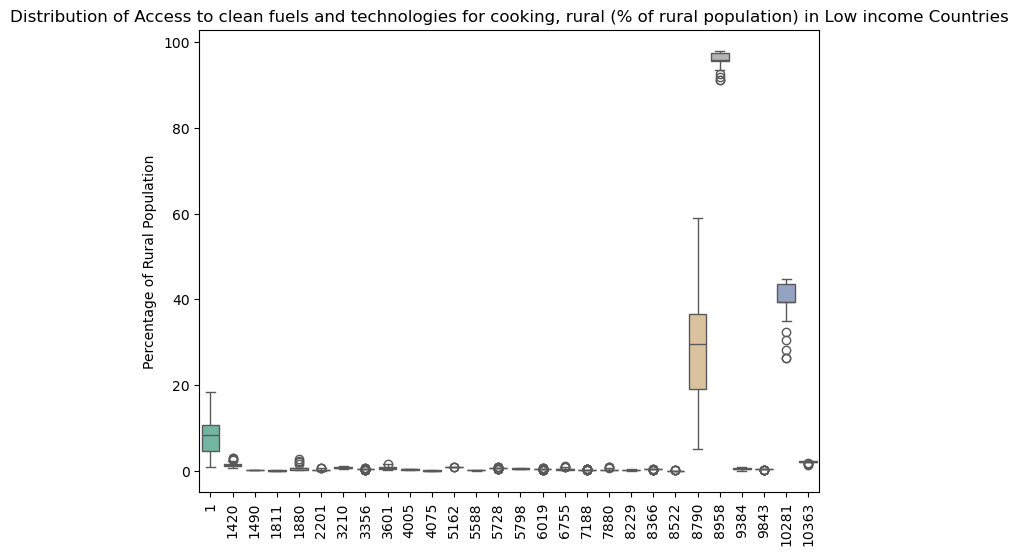

In [130]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=low_income_series.iloc[:, 5:].T, palette="Set2")

plt.title(f"Distribution of {series_name} in {income_level} Countries")
plt.ylabel("Percentage of Rural Population")
plt.xticks(rotation=90)
plt.show()

#### Series: Access to Clean Fuels and Technologies for Cooking, Urban (% of Urban Population)

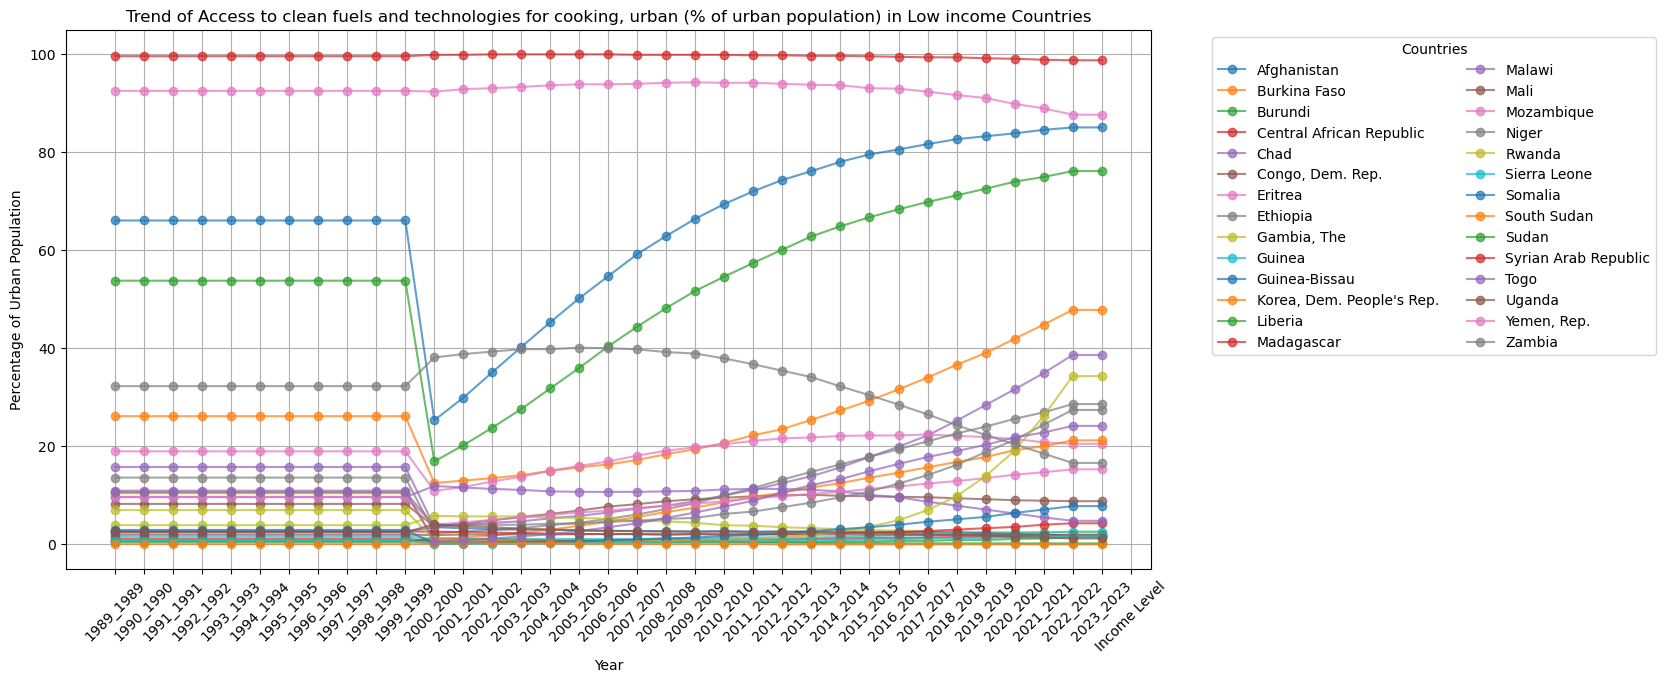

In [132]:
income_level = "Low income"
series_name = "Access to clean fuels and technologies for cooking, urban (% of urban population)"

low_income_series = growth_rates_emissions_energy_prod_income_level_country_df[
    (growth_rates_emissions_energy_prod_income_level_country_df["Income Level"] == income_level) &
    (growth_rates_emissions_energy_prod_income_level_country_df["Series Name"] == series_name)
]

years = low_income_series.iloc[:, 5:].columns

low_income_series.iloc[:, 5:] = low_income_series.iloc[:, 5:].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(14, 7))
for index, row in low_income_series.iterrows():
    plt.plot(years, row.iloc[5:], label=row["Country Name"], linestyle="-", marker="o", alpha=0.7)

plt.title(f"Trend of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Urban Population")
plt.xticks(rotation=45)
plt.legend(title="Countries", bbox_to_anchor=(1.05, 1), loc="upper left", ncol=2)
plt.grid(True)
plt.show()

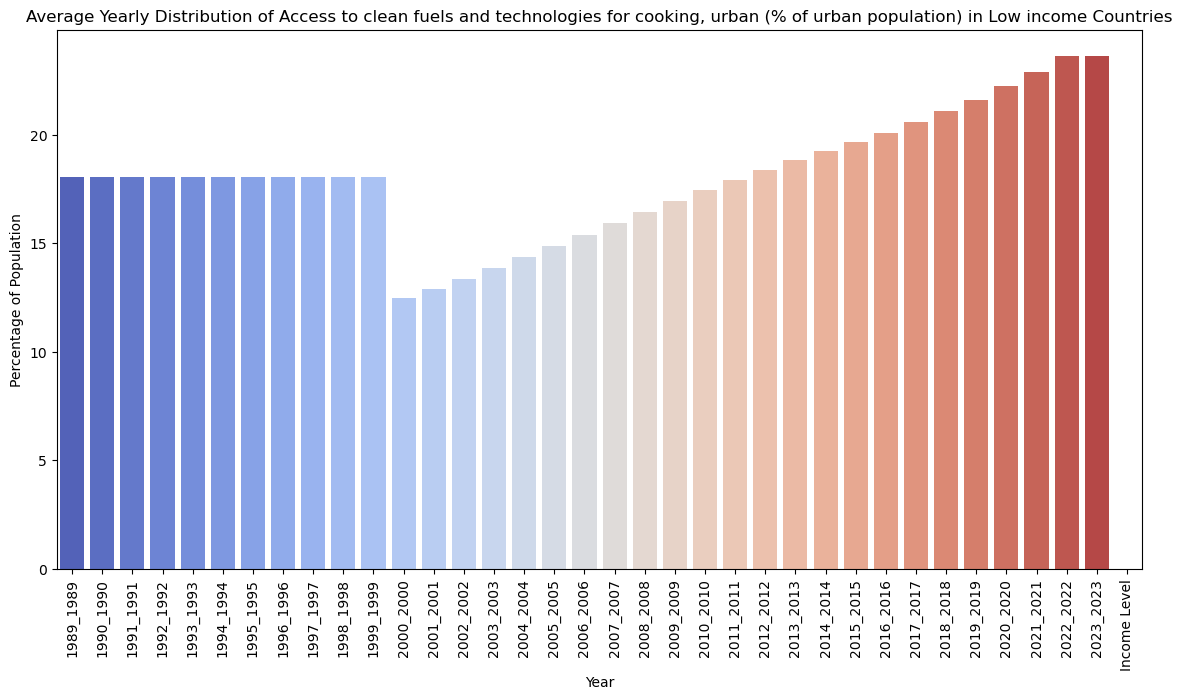

In [133]:
yearly_avg = low_income_series.iloc[:, 5:].mean().reset_index()
yearly_avg.columns = ["Year", "Average Value"]
yearly_avg["Year"] = yearly_avg["Year"].astype(str)

plt.figure(figsize=(14, 7))

sns.barplot(x="Year", y="Average Value", hue="Year", data=yearly_avg, palette="coolwarm", legend=False)

plt.title(f"Average Yearly Distribution of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Population")
plt.xticks(rotation=90)
plt.show()

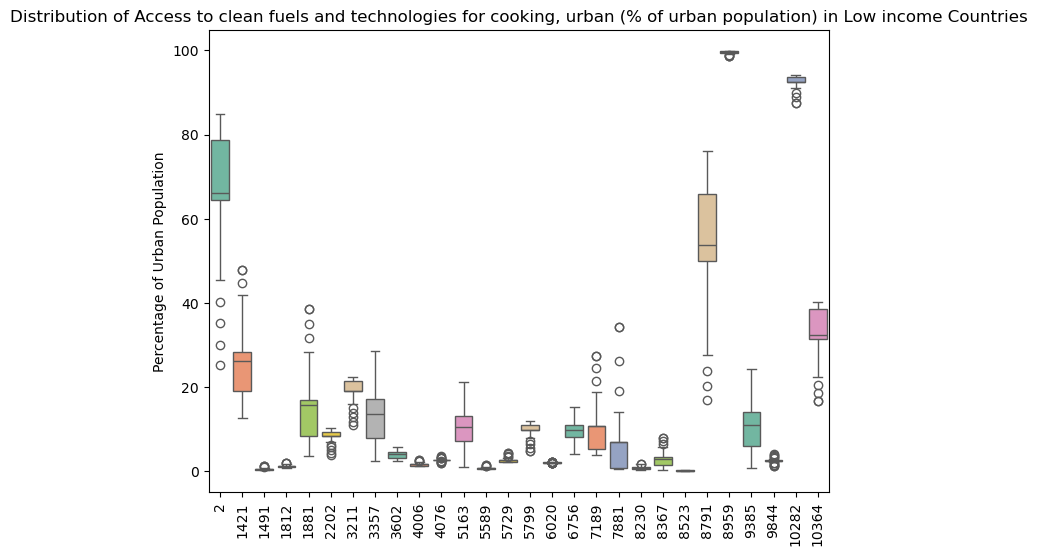

In [134]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=low_income_series.iloc[:, 5:].T, palette="Set2")

plt.title(f"Distribution of {series_name} in {income_level} Countries")
plt.ylabel("Percentage of Urban Population")
plt.xticks(rotation=90)
plt.show()

#### Series: Access to Electricity (% of Population)

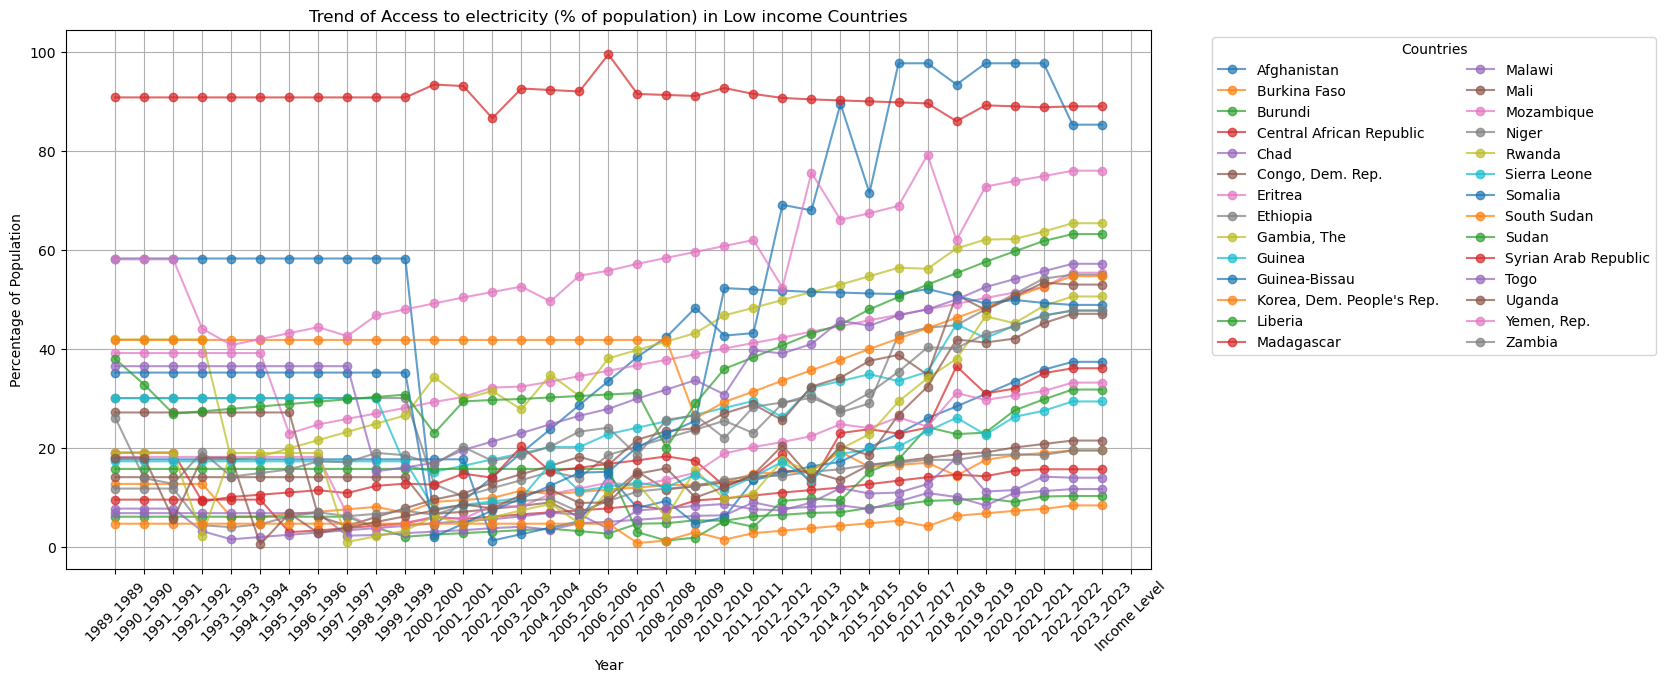

In [136]:
income_level = "Low income"
series_name = "Access to electricity (% of population)"

low_income_series = growth_rates_emissions_energy_prod_income_level_country_df[
    (growth_rates_emissions_energy_prod_income_level_country_df["Income Level"] == income_level) &
    (growth_rates_emissions_energy_prod_income_level_country_df["Series Name"] == series_name)
]

years = low_income_series.iloc[:, 5:].columns

low_income_series.iloc[:, 5:] = low_income_series.iloc[:, 5:].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(14, 7))
for index, row in low_income_series.iterrows():
    plt.plot(years, row.iloc[5:], label=row["Country Name"], linestyle="-", marker="o", alpha=0.7)

plt.title(f"Trend of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Population")
plt.xticks(rotation=45)
plt.legend(title="Countries", bbox_to_anchor=(1.05, 1), loc="upper left", ncol=2)
plt.grid(True)
plt.show()

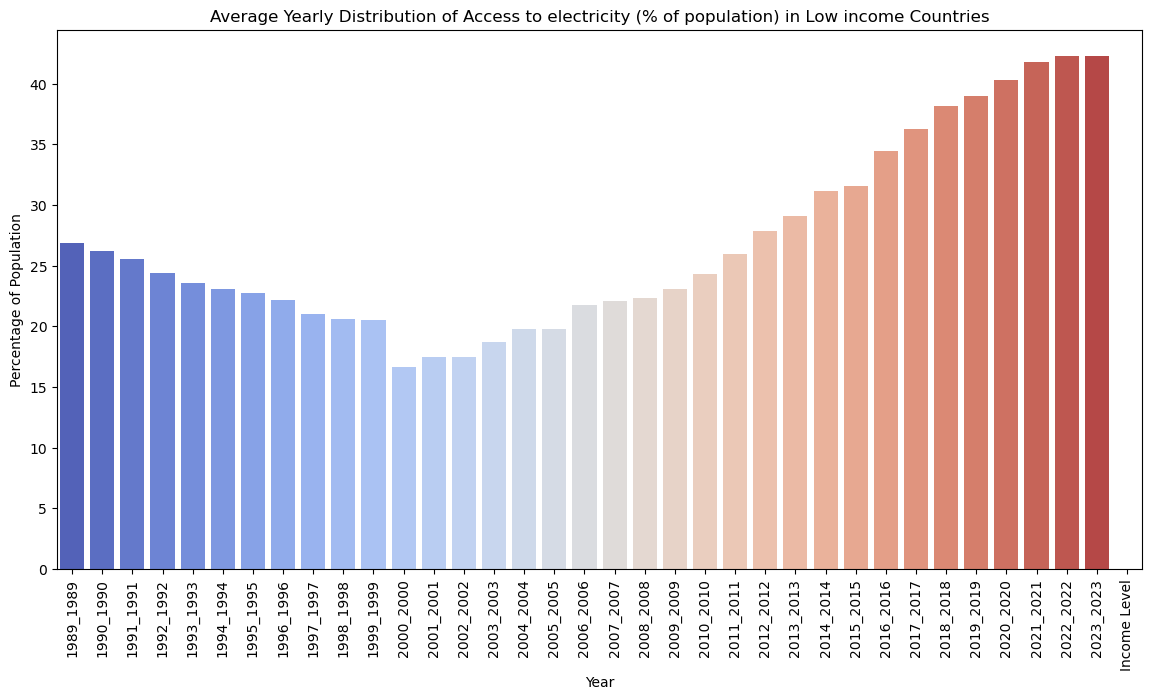

In [137]:
yearly_avg = low_income_series.iloc[:, 5:].mean().reset_index()
yearly_avg.columns = ["Year", "Average Value"]
yearly_avg["Year"] = yearly_avg["Year"].astype(str)

plt.figure(figsize=(14, 7))

sns.barplot(x="Year", y="Average Value", hue="Year", data=yearly_avg, palette="coolwarm", legend=False)

plt.title(f"Average Yearly Distribution of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Population")
plt.xticks(rotation=90)
plt.show()

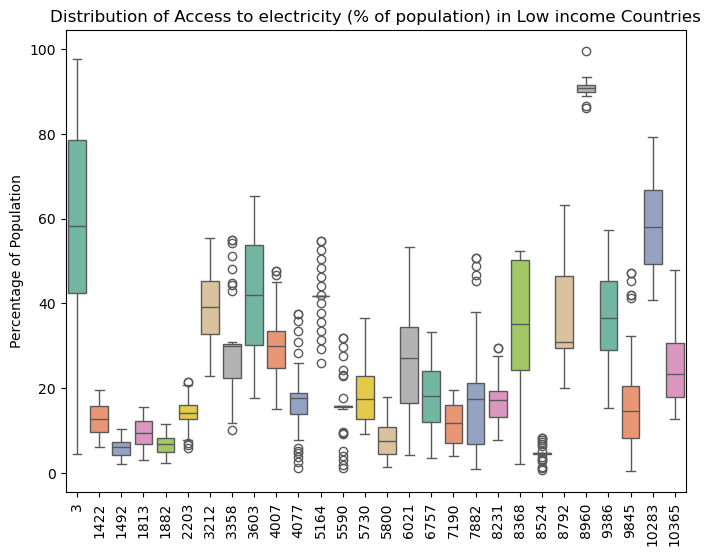

In [138]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=low_income_series.iloc[:, 5:].T, palette="Set2")

plt.title(f"Distribution of {series_name} in {income_level} Countries")
plt.ylabel("Percentage of Population")
plt.xticks(rotation=90)
plt.show()

#### Series: Access to Electricity, Rural (% of Rural Population)

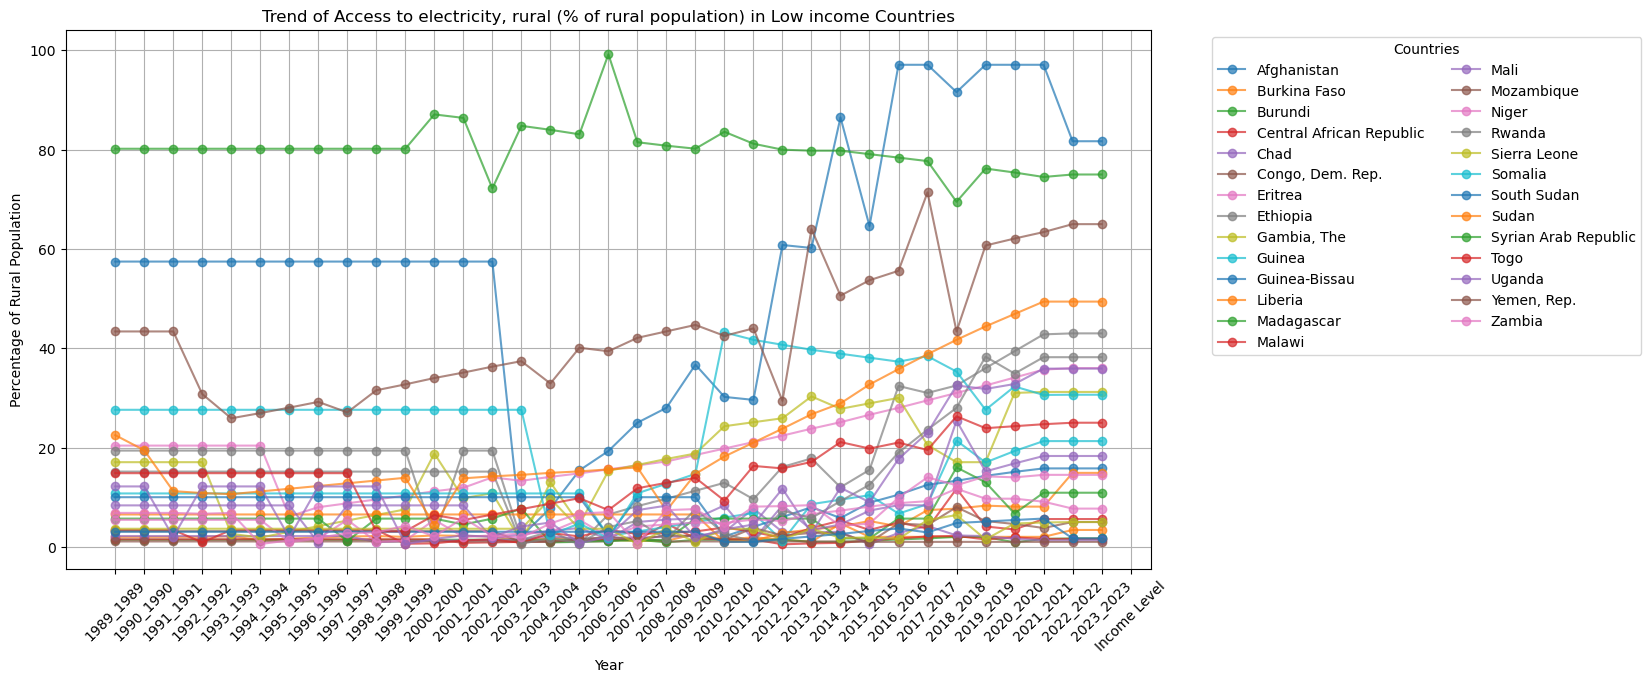

In [176]:
income_level = "Low income"
series_name = "Access to electricity, rural (% of rural population)"

low_income_series = growth_rates_emissions_energy_prod_income_level_country_df[
    (growth_rates_emissions_energy_prod_income_level_country_df["Income Level"] == income_level) &
    (growth_rates_emissions_energy_prod_income_level_country_df["Series Name"] == series_name)
]

years = low_income_series.iloc[:, 5:].columns

low_income_series.iloc[:, 5:] = low_income_series.iloc[:, 5:].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(14, 7))
for index, row in low_income_series.iterrows():
    plt.plot(years, row.iloc[5:], label=row["Country Name"], linestyle="-", marker="o", alpha=0.7)

plt.title(f"Trend of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Rural Population")
plt.xticks(rotation=45)
plt.legend(title="Countries", bbox_to_anchor=(1.05, 1), loc="upper left", ncol=2)
plt.grid(True)
plt.show()

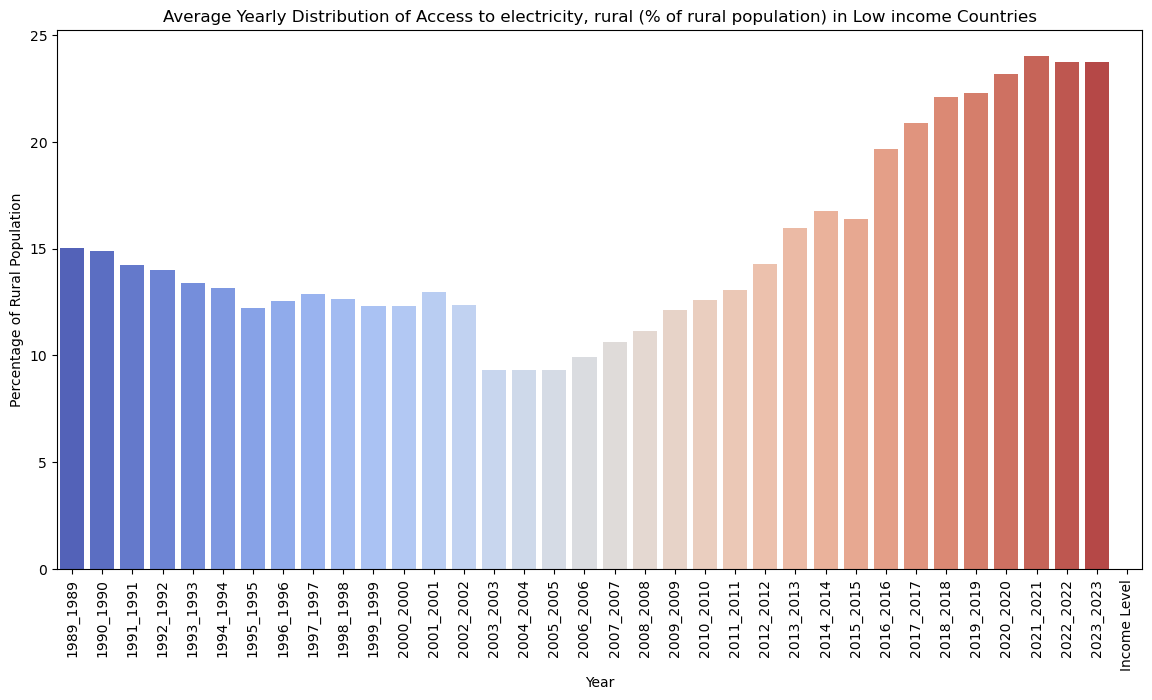

In [178]:
yearly_avg = low_income_series.iloc[:, 5:].mean().reset_index()
yearly_avg.columns = ["Year", "Average Value"]
yearly_avg["Year"] = yearly_avg["Year"].astype(str)

plt.figure(figsize=(14, 7))

sns.barplot(x="Year", y="Average Value", hue="Year", data=yearly_avg, palette="coolwarm", legend=False)

plt.title(f"Average Yearly Distribution of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Rural Population")
plt.xticks(rotation=90)
plt.show()

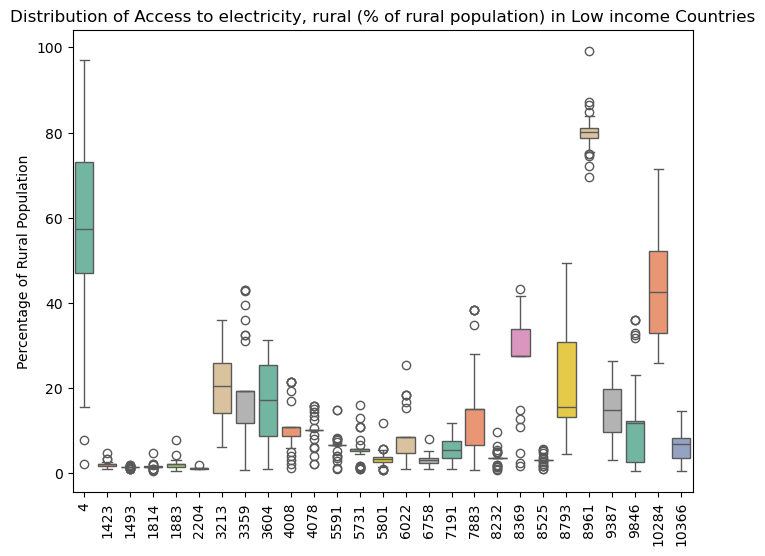

In [180]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=low_income_series.iloc[:, 5:].T, palette="Set2")

plt.title(f"Distribution of {series_name} in {income_level} Countries")
plt.ylabel("Percentage of Rural Population")
plt.xticks(rotation=90)
plt.show()

#### Series: Access to Electricity, Urban (% of Urban Population)

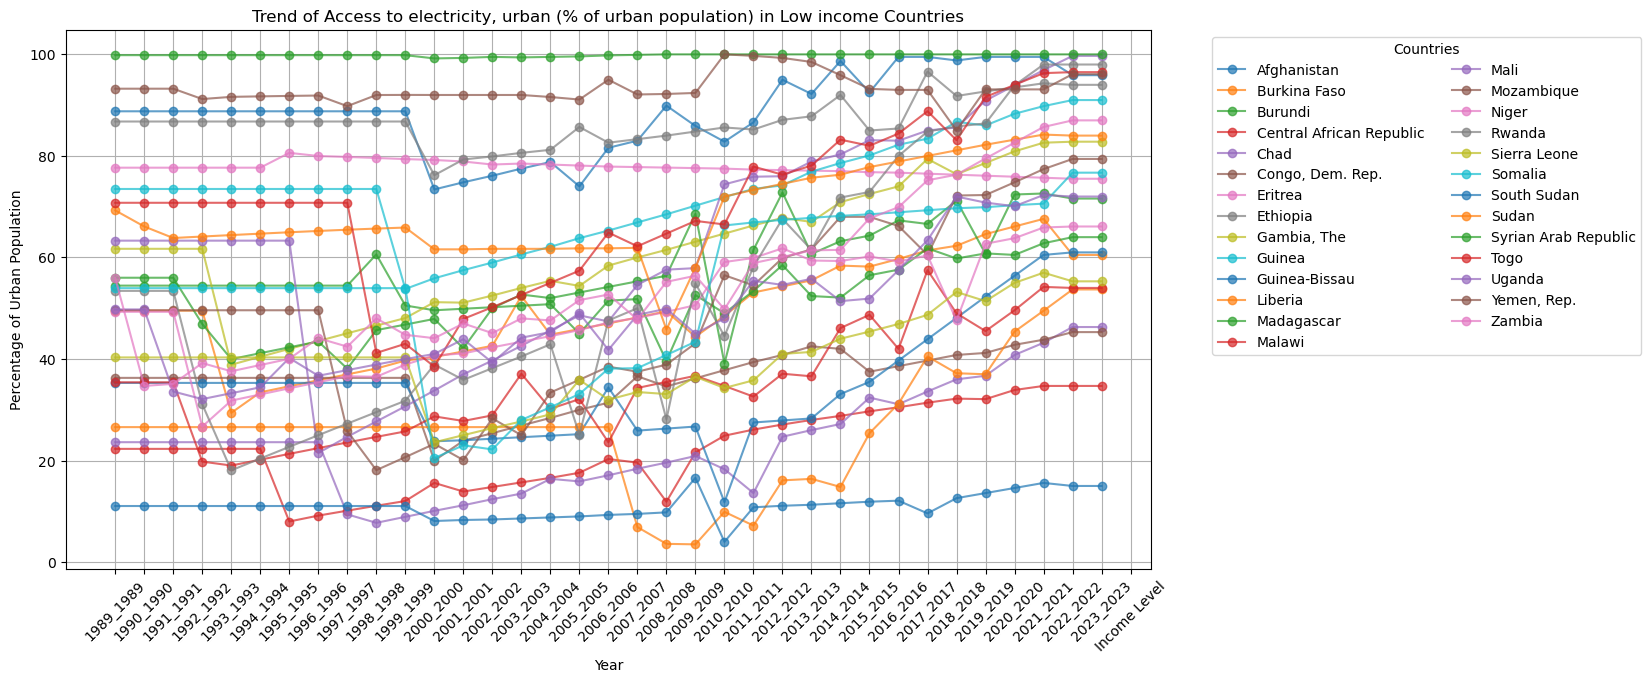

In [187]:
income_level = "Low income"
series_name = "Access to electricity, urban (% of urban population)"

low_income_series = growth_rates_emissions_energy_prod_income_level_country_df[
    (growth_rates_emissions_energy_prod_income_level_country_df["Income Level"] == income_level) &
    (growth_rates_emissions_energy_prod_income_level_country_df["Series Name"] == series_name)
]

years = low_income_series.iloc[:, 5:].columns

low_income_series.iloc[:, 5:] = low_income_series.iloc[:, 5:].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(14, 7))
for index, row in low_income_series.iterrows():
    plt.plot(years, row.iloc[5:], label=row["Country Name"], linestyle="-", marker="o", alpha=0.7)

plt.title(f"Trend of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Urban Population")
plt.xticks(rotation=45)
plt.legend(title="Countries", bbox_to_anchor=(1.05, 1), loc="upper left", ncol=2)
plt.grid(True)
plt.show()

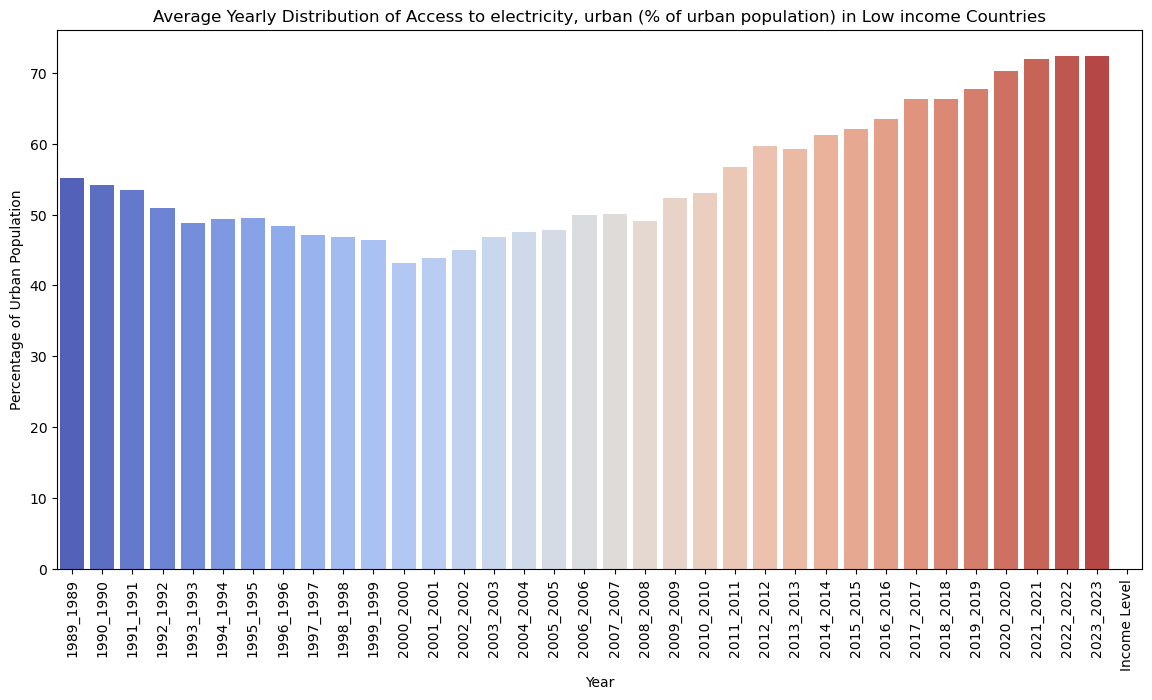

In [189]:
yearly_avg = low_income_series.iloc[:, 5:].mean().reset_index()
yearly_avg.columns = ["Year", "Average Value"]
yearly_avg["Year"] = yearly_avg["Year"].astype(str)

plt.figure(figsize=(14, 7))

sns.barplot(x="Year", y="Average Value", hue="Year", data=yearly_avg, palette="coolwarm", legend=False)

plt.title(f"Average Yearly Distribution of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Urban Population")
plt.xticks(rotation=90)
plt.show()

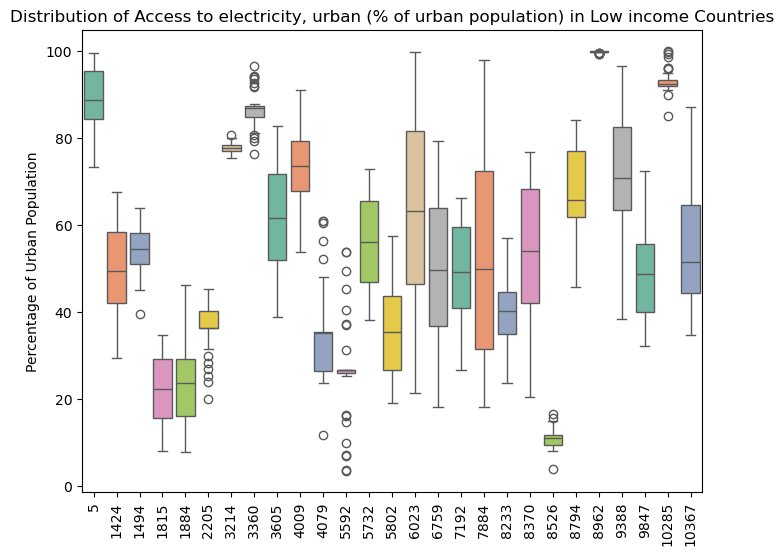

In [191]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=low_income_series.iloc[:, 5:].T, palette="Set2")

plt.title(f"Distribution of {series_name} in {income_level} Countries")
plt.ylabel("Percentage of Urban Population")
plt.xticks(rotation=90)
plt.show()

#### Series: Alternative and nuclear energy (% of total energy use)

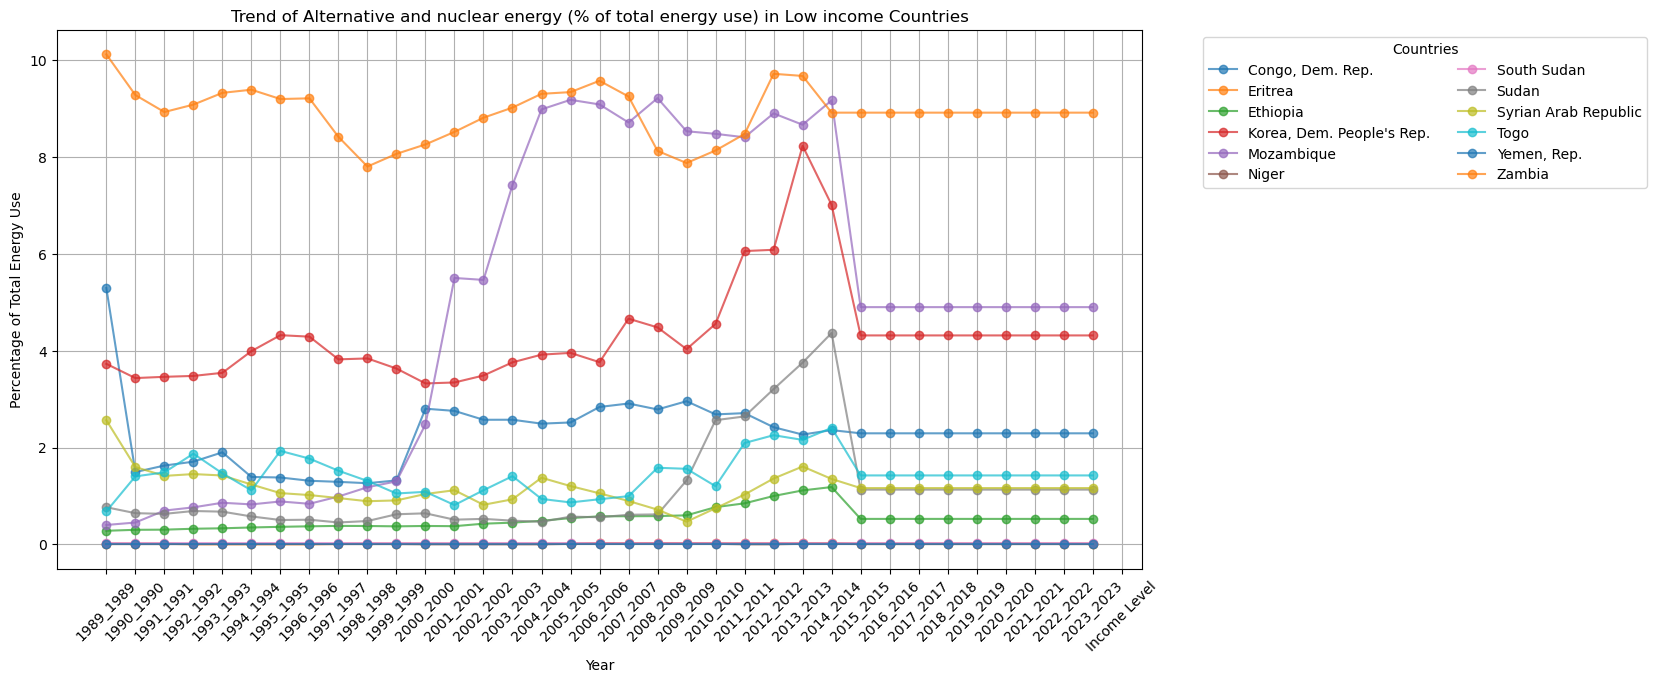

In [196]:
income_level = "Low income"
series_name = "Alternative and nuclear energy (% of total energy use)"

low_income_series = growth_rates_emissions_energy_prod_income_level_country_df[
    (growth_rates_emissions_energy_prod_income_level_country_df["Income Level"] == income_level) &
    (growth_rates_emissions_energy_prod_income_level_country_df["Series Name"] == series_name)
]

years = low_income_series.iloc[:, 5:].columns
low_income_series.iloc[:, 5:] = low_income_series.iloc[:, 5:].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(14, 7))
for index, row in low_income_series.iterrows():
    plt.plot(years, row.iloc[5:], label=row["Country Name"], linestyle="-", marker="o", alpha=0.7)
plt.title(f"Trend of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Total Energy Use")
plt.xticks(rotation=45)
plt.legend(title="Countries", bbox_to_anchor=(1.05, 1), loc="upper left", ncol=2)
plt.grid(True)
plt.show()

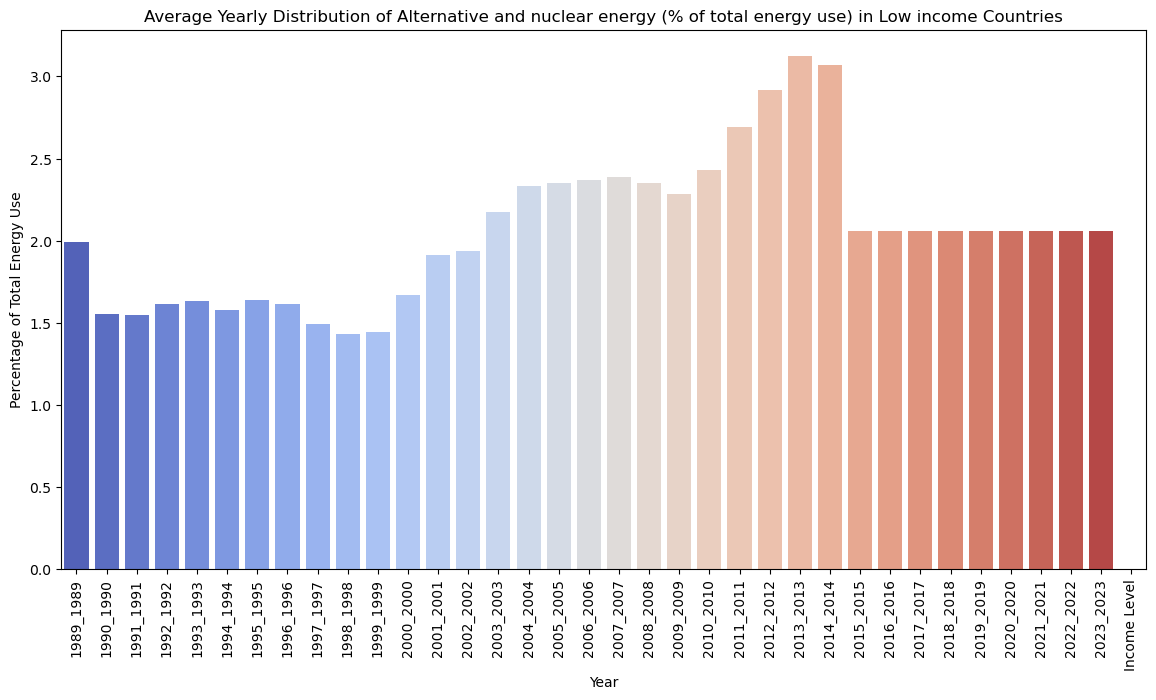

In [198]:
yearly_avg = low_income_series.iloc[:, 5:].mean().reset_index()
yearly_avg.columns = ["Year", "Average Value"]
yearly_avg["Year"] = yearly_avg["Year"].astype(str)

plt.figure(figsize=(14, 7))
sns.barplot(x="Year", y="Average Value", hue="Year", data=yearly_avg, palette="coolwarm", legend=False)
plt.title(f"Average Yearly Distribution of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Total Energy Use")
plt.xticks(rotation=90)
plt.show()

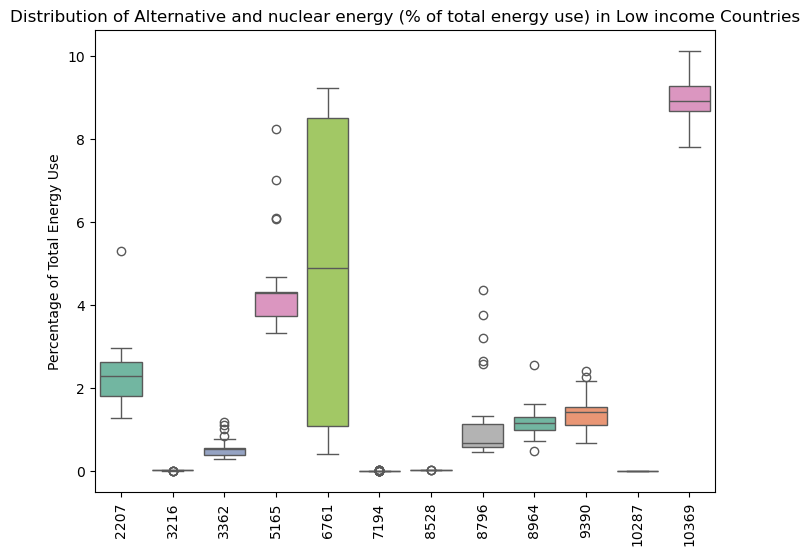

In [200]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=low_income_series.iloc[:, 5:].T, palette="Set2")
plt.title(f"Distribution of {series_name} in {income_level} Countries")
plt.ylabel("Percentage of Total Energy Use")
plt.xticks(rotation=90)
plt.show()

#### Series: Combustible renewables and waste (% of total energy)

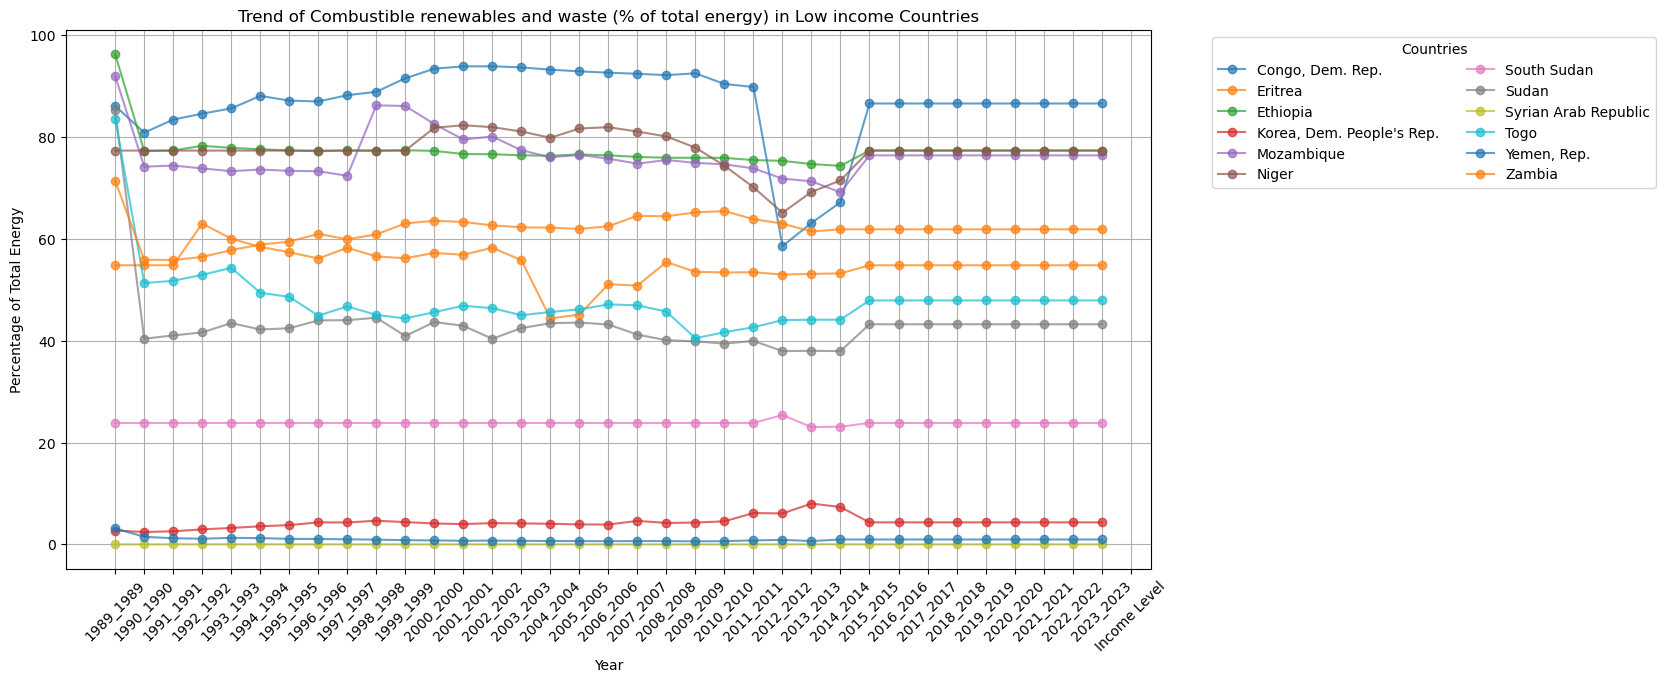

In [203]:
income_level = "Low income"
series_name = "Combustible renewables and waste (% of total energy)"

low_income_series = growth_rates_emissions_energy_prod_income_level_country_df[
    (growth_rates_emissions_energy_prod_income_level_country_df["Income Level"] == income_level) &
    (growth_rates_emissions_energy_prod_income_level_country_df["Series Name"] == series_name)
]

years = low_income_series.iloc[:, 5:].columns
low_income_series.iloc[:, 5:] = low_income_series.iloc[:, 5:].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(14, 7))
for index, row in low_income_series.iterrows():
    plt.plot(years, row.iloc[5:], label=row["Country Name"], linestyle="-", marker="o", alpha=0.7)
plt.title(f"Trend of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Total Energy")
plt.xticks(rotation=45)
plt.legend(title="Countries", bbox_to_anchor=(1.05, 1), loc="upper left", ncol=2)
plt.grid(True)
plt.show()

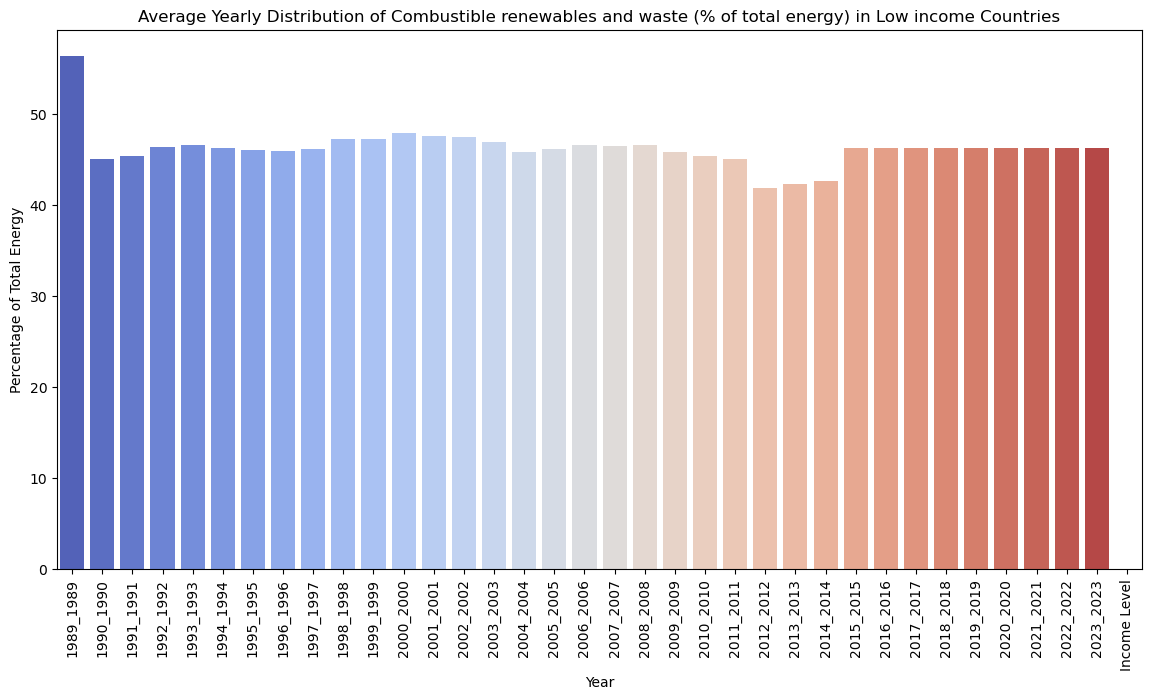

In [205]:
yearly_avg = low_income_series.iloc[:, 5:].mean().reset_index()
yearly_avg.columns = ["Year", "Average Value"]
yearly_avg["Year"] = yearly_avg["Year"].astype(str)

plt.figure(figsize=(14, 7))
sns.barplot(x="Year", y="Average Value", hue="Year", data=yearly_avg, palette="coolwarm", legend=False)
plt.title(f"Average Yearly Distribution of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Total Energy")
plt.xticks(rotation=90)
plt.show()

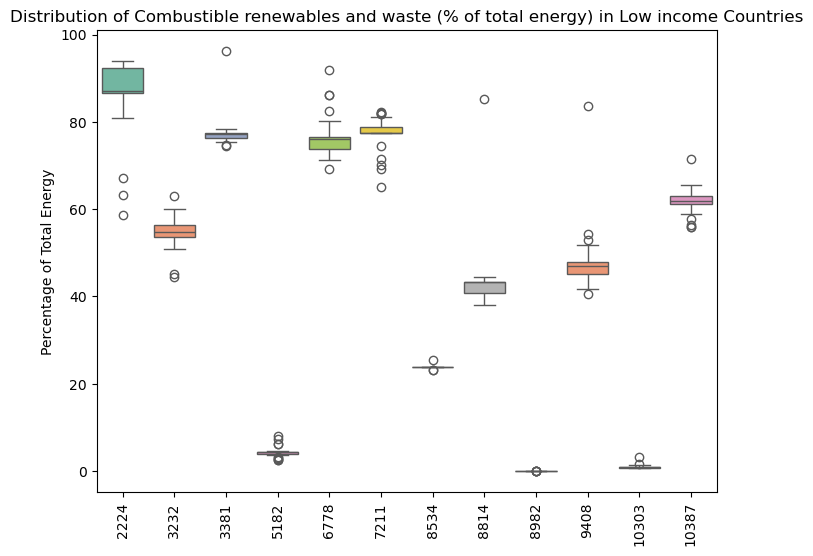

In [207]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=low_income_series.iloc[:, 5:].T, palette="Set2")
plt.title(f"Distribution of {series_name} in {income_level} Countries")
plt.ylabel("Percentage of Total Energy")
plt.xticks(rotation=90)
plt.show()

#### Series: Electric power consumption (kWh per capita)

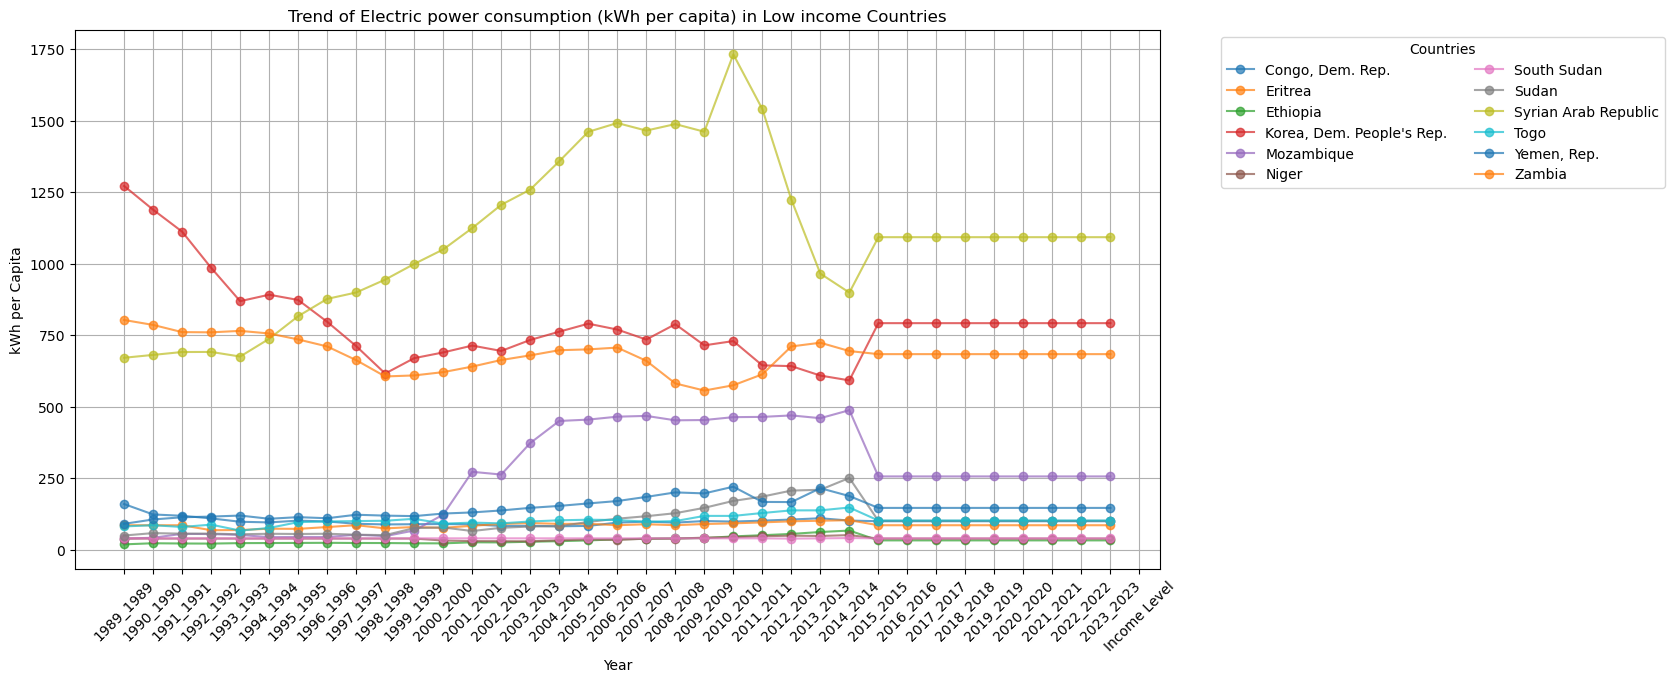

In [210]:
income_level = "Low income"
series_name = "Electric power consumption (kWh per capita)"

low_income_series = growth_rates_emissions_energy_prod_income_level_country_df[
    (growth_rates_emissions_energy_prod_income_level_country_df["Income Level"] == income_level) &
    (growth_rates_emissions_energy_prod_income_level_country_df["Series Name"] == series_name)
]

years = low_income_series.iloc[:, 5:].columns
low_income_series.iloc[:, 5:] = low_income_series.iloc[:, 5:].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(14, 7))
for index, row in low_income_series.iterrows():
    plt.plot(years, row.iloc[5:], label=row["Country Name"], linestyle="-", marker="o", alpha=0.7)
plt.title(f"Trend of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("kWh per Capita")
plt.xticks(rotation=45)
plt.legend(title="Countries", bbox_to_anchor=(1.05, 1), loc="upper left", ncol=2)
plt.grid(True)
plt.show()

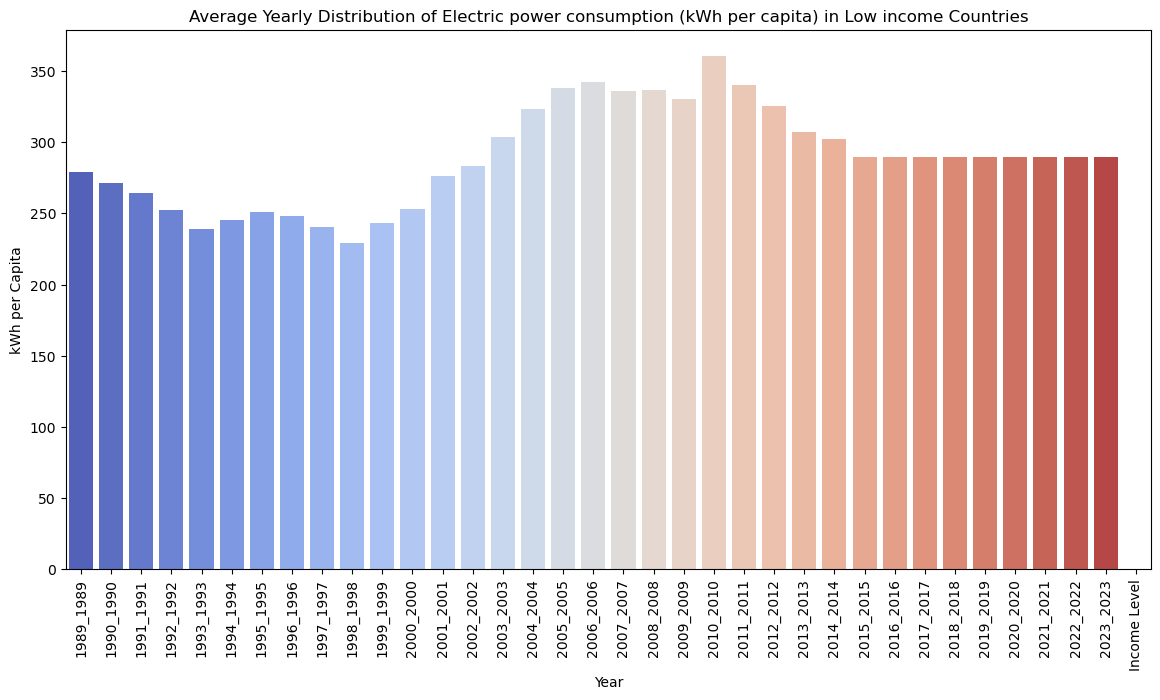

In [212]:
yearly_avg = low_income_series.iloc[:, 5:].mean().reset_index()
yearly_avg.columns = ["Year", "Average Value"]
yearly_avg["Year"] = yearly_avg["Year"].astype(str)

plt.figure(figsize=(14, 7))
sns.barplot(x="Year", y="Average Value", hue="Year", data=yearly_avg, palette="coolwarm", legend=False)
plt.title(f"Average Yearly Distribution of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("kWh per Capita")
plt.xticks(rotation=90)
plt.show()

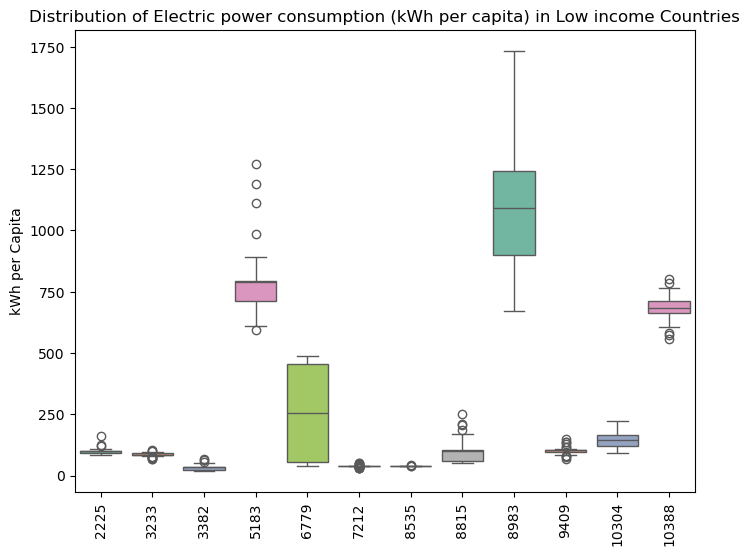

In [214]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=low_income_series.iloc[:, 5:].T, palette="Set2")
plt.title(f"Distribution of {series_name} in {income_level} Countries")
plt.ylabel("kWh per Capita")
plt.xticks(rotation=90)
plt.show()

#### Series: Electric power transmission and distribution losses (% of output)

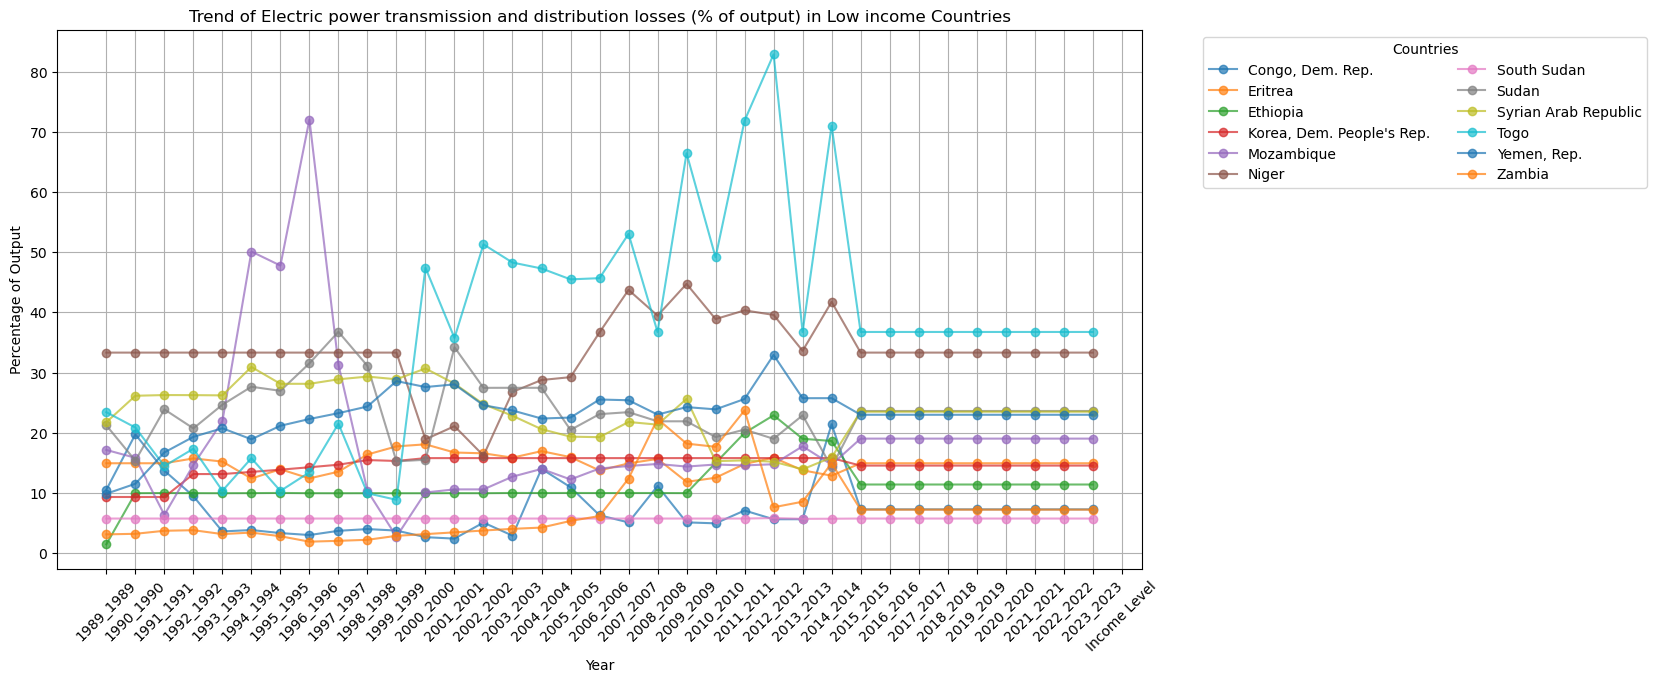

In [217]:
income_level = "Low income"
series_name = "Electric power transmission and distribution losses (% of output)"

low_income_series = growth_rates_emissions_energy_prod_income_level_country_df[
    (growth_rates_emissions_energy_prod_income_level_country_df["Income Level"] == income_level) &
    (growth_rates_emissions_energy_prod_income_level_country_df["Series Name"] == series_name)
]

years = low_income_series.iloc[:, 5:].columns
low_income_series.iloc[:, 5:] = low_income_series.iloc[:, 5:].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(14, 7))
for index, row in low_income_series.iterrows():
    plt.plot(years, row.iloc[5:], label=row["Country Name"], linestyle="-", marker="o", alpha=0.7)
plt.title(f"Trend of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Output")
plt.xticks(rotation=45)
plt.legend(title="Countries", bbox_to_anchor=(1.05, 1), loc="upper left", ncol=2)
plt.grid(True)
plt.show()

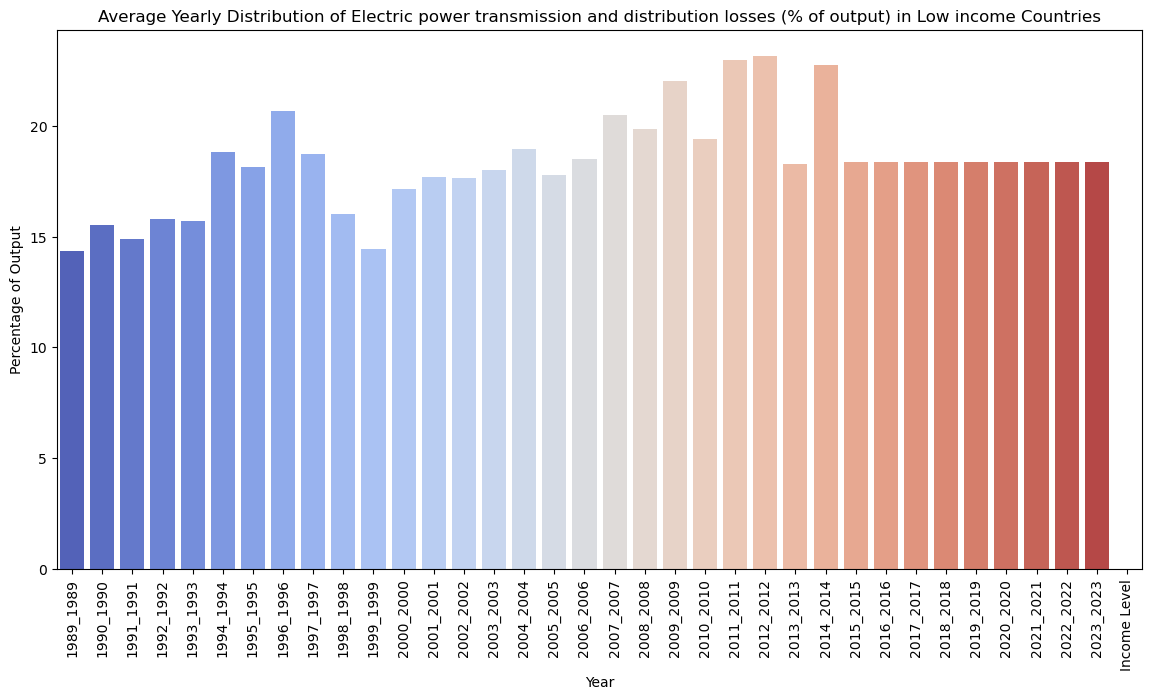

In [219]:
yearly_avg = low_income_series.iloc[:, 5:].mean().reset_index()
yearly_avg.columns = ["Year", "Average Value"]
yearly_avg["Year"] = yearly_avg["Year"].astype(str)

plt.figure(figsize=(14, 7))
sns.barplot(x="Year", y="Average Value", hue="Year", data=yearly_avg, palette="coolwarm", legend=False)
plt.title(f"Average Yearly Distribution of {series_name} in {income_level} Countries")
plt.xlabel("Year")
plt.ylabel("Percentage of Output")
plt.xticks(rotation=90)
plt.show()

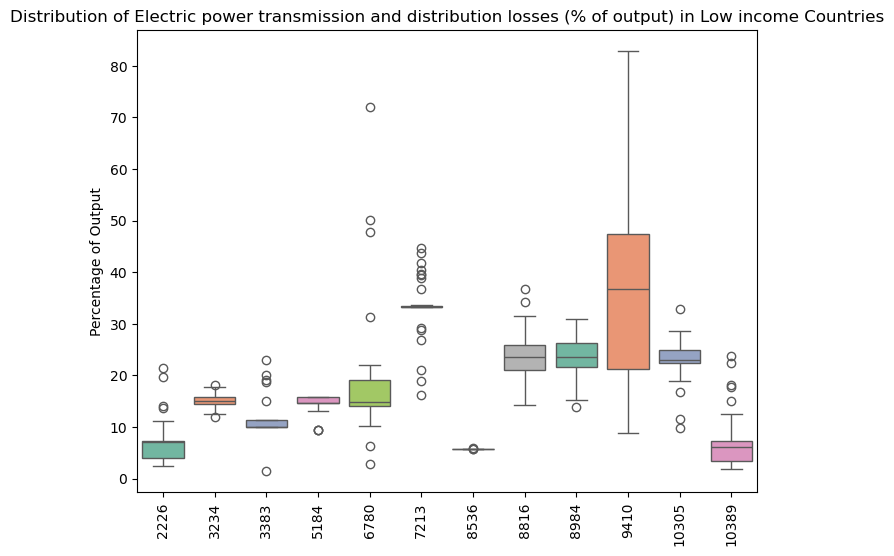

In [221]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=low_income_series.iloc[:, 5:].T, palette="Set2")
plt.title(f"Distribution of {series_name} in {income_level} Countries")
plt.ylabel("Percentage of Output")
plt.xticks(rotation=90)
plt.show()